样本期： 2019-03-01 00:00:00 至 2025-11-01 00:00:00 共 81 个月

教育文化娱乐CPI  ADF=-1.912, p=0.649

训练SnowNLP中心化  ADF=-6.518, p=0.000

至少一个序列平稳，跳过协整检验

情绪→教育文化娱乐CPI  Granger p = 0.678  不拒绝
教育文化娱乐CPI→情绪  Granger p = 0.850  不拒绝


C:\Anaconda\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


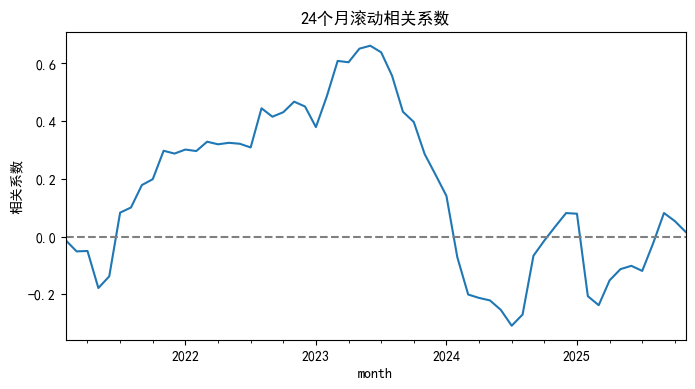

In [38]:
# -*- coding: utf-8 -*-
"""
时间序列精简版：教育文化娱乐 CPI vs 训练SnowNLP中心化
（已去掉 arch，仅保留平稳、协整、Granger、滚动相关）
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint, grangercausalitytests

# 1. 读数据
file_path = r'D:/NJU_WORKPIECE/期末：所有模型月度情感评分+经济指标.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1', index_col=0)
df.index = pd.to_datetime(df.index)

cpi_col = '居民消费价格指数(上年同月＝100)_教育文化娱乐_当期'
sent_col = '训练snownlp中心化'
y1 = df[cpi_col].dropna()
y2 = df[sent_col].dropna()

common_idx = y1.index.intersection(y2.index)
y1, y2 = y1.loc[common_idx], y2.loc[common_idx]
print('样本期：', common_idx[0], '至', common_idx[-1], '共', len(common_idx), '个月')

# 2. 平稳性检验
def adf_test(sr, name):
    res = adfuller(sr, regression='ct')
    print(f'\n{name}  ADF={res[0]:.3f}, p={res[1]:.3f}')
    return res[1] < 0.05

y1_stationary = adf_test(y1, '教育文化娱乐CPI')
y2_stationary = adf_test(y2, '训练SnowNLP中心化')

# 3. 协整
if not y1_stationary and not y2_stationary:
    eg_stat, eg_p, _ = coint(y1, y2, trend='ct')[:3]
    print(f'\nEngle-Granger 协整检验 stat={eg_stat:.3f}, p={eg_p:.3f}')
    cointegrated = eg_p < 0.05
else:
    cointegrated = False
    print('\n至少一个序列平稳，跳过协整检验')

# 4. Granger 因果
maxlag = 6
gc_res  = grangercausalitytests(pd.concat([y2, y1], axis=1), maxlag, verbose=False)
gpval   = gc_res[maxlag][0]['ssr_ftest'][1]      # 只取 p 值

gc_res2 = grangercausalitytests(pd.concat([y1, y2], axis=1), maxlag, verbose=False)
gpval2  = gc_res2[maxlag][0]['ssr_ftest'][1]

print(f'\n情绪→教育文化娱乐CPI  Granger p = {gpval:.3f}  {"拒绝" if gpval<0.05 else "不拒绝"}')
print(f'教育文化娱乐CPI→情绪  Granger p = {gpval2:.3f}  {"拒绝" if gpval2<0.05 else "不拒绝"}')

# 5. 滚动相关
window = 24
rolling_corr = y1.rolling(window).corr(y2).dropna()
plt.figure(figsize=(8, 4))
rolling_corr.plot(title=f'{window}个月滚动相关系数')
plt.axhline(0, color='grey', ls='--')
plt.ylabel('相关系数')
plt.show()

样本期： 2019-03-01 00:00:00 至 2025-11-01 00:00:00 共 81 个月

HS300  ADF=-1.717, p=0.744

SnowNLP标题修正  ADF=-9.348, p=0.000

至少一个序列平稳，跳过协整检验

情绪→教育文化娱乐CPI  Granger p = 0.344  不拒绝
教育文化娱乐CPI→情绪  Granger p = 0.820  不拒绝


C:\Anaconda\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


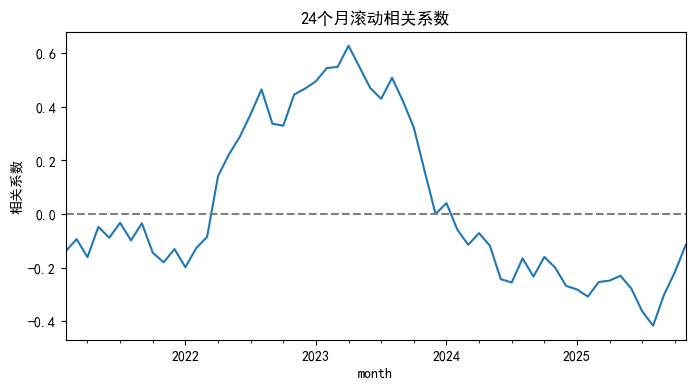

In [1]:
# -*- coding: utf-8 -*-
"""
时间序列精简版：教育文化娱乐 CPI vs 训练SnowNLP中心化
（已去掉 arch，仅保留平稳、协整、Granger、滚动相关）
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint, grangercausalitytests

# 1. 读数据
file_path = r'D:/NJU_WORKPIECE/期末：所有模型月度情感评分+经济指标_差分3.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1', index_col=0)
df.index = pd.to_datetime(df.index)

cpi_col = 'HS300'
sent_col = 'snownlp标题修正'
y1 = df[cpi_col].dropna()
y2 = df[sent_col].dropna()

common_idx = y1.index.intersection(y2.index)
y1, y2 = y1.loc[common_idx], y2.loc[common_idx]
print('样本期：', common_idx[0], '至', common_idx[-1], '共', len(common_idx), '个月')

# 2. 平稳性检验
def adf_test(sr, name):
    res = adfuller(sr, regression='ct')
    print(f'\n{name}  ADF={res[0]:.3f}, p={res[1]:.3f}')
    return res[1] < 0.05

y1_stationary = adf_test(y1, 'HS300')
y2_stationary = adf_test(y2, 'SnowNLP标题修正')

# 3. 协整
if not y1_stationary and not y2_stationary:
    eg_stat, eg_p, _ = coint(y1, y2, trend='ct')[:3]
    print(f'\nEngle-Granger 协整检验 stat={eg_stat:.3f}, p={eg_p:.3f}')
    cointegrated = eg_p < 0.05
else:
    cointegrated = False
    print('\n至少一个序列平稳，跳过协整检验')


# 4. Granger 因果
maxlag = 6
gc_res  = grangercausalitytests(pd.concat([y2, y1], axis=1), maxlag, verbose=False)
gpval   = gc_res[maxlag][0]['ssr_ftest'][1]      # 只取 p 值

gc_res2 = grangercausalitytests(pd.concat([y1, y2], axis=1), maxlag, verbose=False)
gpval2  = gc_res2[maxlag][0]['ssr_ftest'][1]

print(f'\n情绪→教育文化娱乐CPI  Granger p = {gpval:.3f}  {"拒绝" if gpval<0.05 else "不拒绝"}')
print(f'教育文化娱乐CPI→情绪  Granger p = {gpval2:.3f}  {"拒绝" if gpval2<0.05 else "不拒绝"}')

# 5. 滚动相关
window = 24
rolling_corr = y1.rolling(window).corr(y2).dropna()
plt.figure(figsize=(8, 4))
rolling_corr.plot(title=f'{window}个月滚动相关系数')
plt.axhline(0, color='grey', ls='--')
plt.ylabel('相关系数')
plt.show()

样本期： 2019-03-01 00:00:00 至 2025-11-01 00:00:00 共 81 个月

HS300  ADF=-1.912, p=0.649

训练SnowNLP原始得分  ADF=-2.737, p=0.221

Engle-Granger 协整检验 stat=-2.172, p=0.694

情绪→CPI  Granger p = 0.492  不拒绝
CPI→情绪  Granger p = 0.557  不拒绝


C:\Anaconda\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


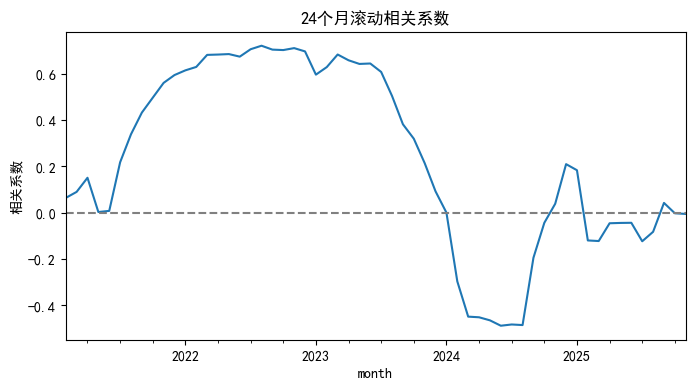

In [2]:
# -*- coding: utf-8 -*-
"""
时间序列精简版：教育文化娱乐 CPI vs 训练SnowNLP中心化
（已去掉 arch，仅保留平稳、协整、Granger、滚动相关）
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint, grangercausalitytests

# 1. 读数据
file_path = r'D:/NJU_WORKPIECE/期末：所有模型月度情感评分+经济指标.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1', index_col=0)
df.index = pd.to_datetime(df.index)

cpi_col = '居民消费价格指数(上年同月＝100)_教育文化娱乐_当期'
sent_col = '训练snownlp原始得分'
y1 = df[cpi_col].dropna()
y2 = df[sent_col].dropna()

common_idx = y1.index.intersection(y2.index)
y1, y2 = y1.loc[common_idx], y2.loc[common_idx]
print('样本期：', common_idx[0], '至', common_idx[-1], '共', len(common_idx), '个月')

# 2. 平稳性检验
def adf_test(sr, name):
    res = adfuller(sr, regression='ct')
    print(f'\n{name}  ADF={res[0]:.3f}, p={res[1]:.3f}')
    return res[1] < 0.05

y1_stationary = adf_test(y1, 'HS300')
y2_stationary = adf_test(y2, '训练SnowNLP原始得分')

# 3. 协整
if not y1_stationary and not y2_stationary:
    eg_stat, eg_p, _ = coint(y1, y2, trend='ct')[:3]
    print(f'\nEngle-Granger 协整检验 stat={eg_stat:.3f}, p={eg_p:.3f}')
    cointegrated = eg_p < 0.05
else:
    cointegrated = False
    print('\n至少一个序列平稳，跳过协整检验')

# 4. Granger 因果
maxlag = 6
gc_res  = grangercausalitytests(pd.concat([y2, y1], axis=1), maxlag, verbose=False)
gpval   = gc_res[maxlag][0]['ssr_ftest'][1]      # 只取 p 值

gc_res2 = grangercausalitytests(pd.concat([y1, y2], axis=1), maxlag, verbose=False)
gpval2  = gc_res2[maxlag][0]['ssr_ftest'][1]

print(f'\n情绪→CPI  Granger p = {gpval:.3f}  {"拒绝" if gpval<0.05 else "不拒绝"}')
print(f'CPI→情绪  Granger p = {gpval2:.3f}  {"拒绝" if gpval2<0.05 else "不拒绝"}')

# 5. 滚动相关
window = 24
rolling_corr = y1.rolling(window).corr(y2).dropna()
plt.figure(figsize=(8, 4))
rolling_corr.plot(title=f'{window}个月滚动相关系数')
plt.axhline(0, color='grey', ls='--')
plt.ylabel('相关系数')
plt.show()

样本期： 2019-03-01 00:00:00 至 2025-11-01 00:00:00 共 81 个月

教育文化娱乐CPI  ADF=-1.912, p=0.649

SnowNLP原始得分  ADF=-9.093, p=0.000

至少一个序列平稳，跳过协整检验

情绪→CPI  Granger p = 0.291  不拒绝
CPI→情绪  Granger p = 0.701  不拒绝


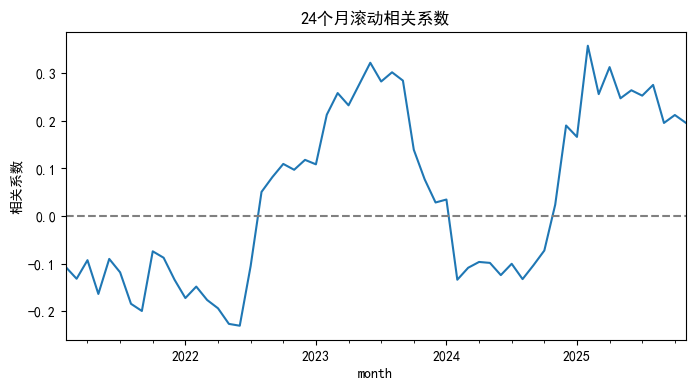

In [21]:
# -*- coding: utf-8 -*-
"""
时间序列精简版：教育文化娱乐 CPI vs 训练SnowNLP中心化
（已去掉 arch，仅保留平稳、协整、Granger、滚动相关）
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint, grangercausalitytests

# 1. 读数据
file_path = r'D:/NJU_WORKPIECE/期末：所有模型月度情感评分+经济指标.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1', index_col=0)
df.index = pd.to_datetime(df.index)

cpi_col = '居民消费价格指数(上年同月＝100)_教育文化娱乐_当期'
sent_col = 'snownlp原始得分'
y1 = df[cpi_col].dropna()
y2 = df[sent_col].dropna()

common_idx = y1.index.intersection(y2.index)
y1, y2 = y1.loc[common_idx], y2.loc[common_idx]
print('样本期：', common_idx[0], '至', common_idx[-1], '共', len(common_idx), '个月')

# 2. 平稳性检验
def adf_test(sr, name):
    res = adfuller(sr, regression='ct')
    print(f'\n{name}  ADF={res[0]:.3f}, p={res[1]:.3f}')
    return res[1] < 0.05

y1_stationary = adf_test(y1, '教育文化娱乐CPI')
y2_stationary = adf_test(y2, 'SnowNLP原始得分')

# 3. 协整
if not y1_stationary and not y2_stationary:
    eg_stat, eg_p, _ = coint(y1, y2, trend='ct')[:3]
    print(f'\nEngle-Granger 协整检验 stat={eg_stat:.3f}, p={eg_p:.3f}')
    cointegrated = eg_p < 0.05
else:
    cointegrated = False
    print('\n至少一个序列平稳，跳过协整检验')

# 4. Granger 因果
maxlag = 6
gc_res  = grangercausalitytests(pd.concat([y2, y1], axis=1), maxlag, verbose=False)
gpval   = gc_res[maxlag][0]['ssr_ftest'][1]      # 只取 p 值

gc_res2 = grangercausalitytests(pd.concat([y1, y2], axis=1), maxlag, verbose=False)
gpval2  = gc_res2[maxlag][0]['ssr_ftest'][1]

print(f'\n情绪→CPI  Granger p = {gpval:.3f}  {"拒绝" if gpval<0.05 else "不拒绝"}')
print(f'CPI→情绪  Granger p = {gpval2:.3f}  {"拒绝" if gpval2<0.05 else "不拒绝"}')

# 5. 滚动相关
window = 24
rolling_corr = y1.rolling(window).corr(y2).dropna()
plt.figure(figsize=(8, 4))
rolling_corr.plot(title=f'{window}个月滚动相关系数')
plt.axhline(0, color='grey', ls='--')
plt.ylabel('相关系数')
plt.show()

样本期： 2019-03-01 00:00:00 至 2025-11-01 00:00:00 共 81 个月

教育文化娱乐CPI  ADF=-1.912, p=0.649

SnowNLP中心化  ADF=-9.439, p=0.000

至少一个序列平稳，跳过协整检验

情绪→CPI  Granger p = 0.248  不拒绝
CPI→情绪  Granger p = 0.526  不拒绝


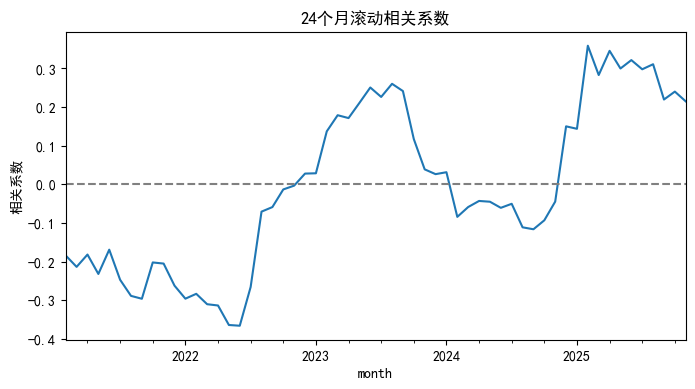

In [25]:
# -*- coding: utf-8 -*-
"""
时间序列精简版：教育文化娱乐 CPI vs 训练SnowNLP中心化
（已去掉 arch，仅保留平稳、协整、Granger、滚动相关）
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint, grangercausalitytests

# 1. 读数据
file_path = r'D:/NJU_WORKPIECE/期末：所有模型月度情感评分+经济指标.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1', index_col=0)
df.index = pd.to_datetime(df.index)

cpi_col = '居民消费价格指数(上年同月＝100)_教育文化娱乐_当期'
sent_col = 'snownlp中心化'
y1 = df[cpi_col].dropna()
y2 = df[sent_col].dropna()

common_idx = y1.index.intersection(y2.index)
y1, y2 = y1.loc[common_idx], y2.loc[common_idx]
print('样本期：', common_idx[0], '至', common_idx[-1], '共', len(common_idx), '个月')

# 2. 平稳性检验
def adf_test(sr, name):
    res = adfuller(sr, regression='ct')
    print(f'\n{name}  ADF={res[0]:.3f}, p={res[1]:.3f}')
    return res[1] < 0.05

y1_stationary = adf_test(y1, '教育文化娱乐CPI')
y2_stationary = adf_test(y2, 'SnowNLP中心化')

# 3. 协整
if not y1_stationary and not y2_stationary:
    eg_stat, eg_p, _ = coint(y1, y2, trend='ct')[:3]
    print(f'\nEngle-Granger 协整检验 stat={eg_stat:.3f}, p={eg_p:.3f}')
    cointegrated = eg_p < 0.05
else:
    cointegrated = False
    print('\n至少一个序列平稳，跳过协整检验')

# 4. Granger 因果
maxlag = 6
gc_res  = grangercausalitytests(pd.concat([y2, y1], axis=1), maxlag, verbose=False)
gpval   = gc_res[maxlag][0]['ssr_ftest'][1]      # 只取 p 值

gc_res2 = grangercausalitytests(pd.concat([y1, y2], axis=1), maxlag, verbose=False)
gpval2  = gc_res2[maxlag][0]['ssr_ftest'][1]

print(f'\n情绪→CPI  Granger p = {gpval:.3f}  {"拒绝" if gpval<0.05 else "不拒绝"}')
print(f'CPI→情绪  Granger p = {gpval2:.3f}  {"拒绝" if gpval2<0.05 else "不拒绝"}')

# 5. 滚动相关
window = 24
rolling_corr = y1.rolling(window).corr(y2).dropna()
plt.figure(figsize=(8, 4))
rolling_corr.plot(title=f'{window}个月滚动相关系数')
plt.axhline(0, color='grey', ls='--')
plt.ylabel('相关系数')
plt.show()

样本期： 2019-03-01 00:00:00 至 2025-11-01 00:00:00 共 81 个月

教育文化娱乐CPI  ADF=-1.912, p=0.649

SnowNLP标题修正  ADF=-9.348, p=0.000

至少一个序列平稳，跳过协整检验

情绪→CPI  Granger p = 0.344  不拒绝
CPI→情绪  Granger p = 0.284  不拒绝


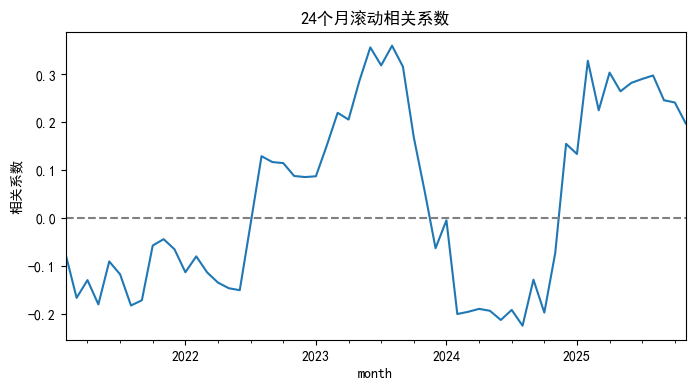

In [26]:
# -*- coding: utf-8 -*-
"""
时间序列精简版：教育文化娱乐 CPI vs 训练SnowNLP中心化
（已去掉 arch，仅保留平稳、协整、Granger、滚动相关）
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint, grangercausalitytests

# 1. 读数据
file_path = r'D:/NJU_WORKPIECE/期末：所有模型月度情感评分+经济指标.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1', index_col=0)
df.index = pd.to_datetime(df.index)

cpi_col = '居民消费价格指数(上年同月＝100)_教育文化娱乐_当期'
sent_col = 'snownlp标题修正'
y1 = df[cpi_col].dropna()
y2 = df[sent_col].dropna()

common_idx = y1.index.intersection(y2.index)
y1, y2 = y1.loc[common_idx], y2.loc[common_idx]
print('样本期：', common_idx[0], '至', common_idx[-1], '共', len(common_idx), '个月')

# 2. 平稳性检验
def adf_test(sr, name):
    res = adfuller(sr, regression='ct')
    print(f'\n{name}  ADF={res[0]:.3f}, p={res[1]:.3f}')
    return res[1] < 0.05

y1_stationary = adf_test(y1, '教育文化娱乐CPI')
y2_stationary = adf_test(y2, 'SnowNLP标题修正')

# 3. 协整
if not y1_stationary and not y2_stationary:
    eg_stat, eg_p, _ = coint(y1, y2, trend='ct')[:3]
    print(f'\nEngle-Granger 协整检验 stat={eg_stat:.3f}, p={eg_p:.3f}')
    cointegrated = eg_p < 0.05
else:
    cointegrated = False
    print('\n至少一个序列平稳，跳过协整检验')

# 4. Granger 因果
maxlag = 6
gc_res  = grangercausalitytests(pd.concat([y2, y1], axis=1), maxlag, verbose=False)
gpval   = gc_res[maxlag][0]['ssr_ftest'][1]      # 只取 p 值

gc_res2 = grangercausalitytests(pd.concat([y1, y2], axis=1), maxlag, verbose=False)
gpval2  = gc_res2[maxlag][0]['ssr_ftest'][1]

print(f'\n情绪→CPI  Granger p = {gpval:.3f}  {"拒绝" if gpval<0.05 else "不拒绝"}')
print(f'CPI→情绪  Granger p = {gpval2:.3f}  {"拒绝" if gpval2<0.05 else "不拒绝"}')

# 5. 滚动相关
window = 24
rolling_corr = y1.rolling(window).corr(y2).dropna()
plt.figure(figsize=(8, 4))
rolling_corr.plot(title=f'{window}个月滚动相关系数')
plt.axhline(0, color='grey', ls='--')
plt.ylabel('相关系数')
plt.show()

样本期： 2019-03-01 00:00:00 至 2025-11-01 00:00:00 共 81 个月

居民消费价格指数  ADF=-2.548, p=0.304

训练SnowNLP原始得分  ADF=-2.737, p=0.221

Engle-Granger 协整检验 stat=-2.022, p=0.763

情绪→CPI  Granger p = 0.886  不拒绝
CPI→情绪  Granger p = 0.734  不拒绝


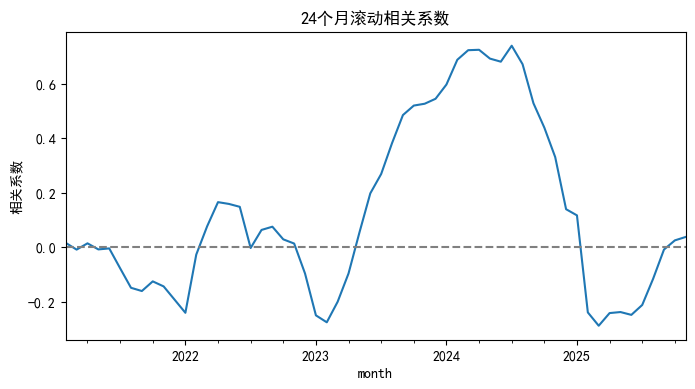

In [30]:
# -*- coding: utf-8 -*-
"""
时间序列精简版：教育文化娱乐 CPI vs 训练SnowNLP中心化
（已去掉 arch，仅保留平稳、协整、Granger、滚动相关）
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint, grangercausalitytests

# 1. 读数据
file_path = r'D:/NJU_WORKPIECE/期末：所有模型月度情感评分+经济指标.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1', index_col=0)
df.index = pd.to_datetime(df.index)

cpi_col = '居民消费价格指数(上年同月＝100)_当期'
sent_col = '训练snownlp原始得分'
y1 = df[cpi_col].dropna()
y2 = df[sent_col].dropna()

common_idx = y1.index.intersection(y2.index)
y1, y2 = y1.loc[common_idx], y2.loc[common_idx]
print('样本期：', common_idx[0], '至', common_idx[-1], '共', len(common_idx), '个月')

# 2. 平稳性检验
def adf_test(sr, name):
    res = adfuller(sr, regression='ct')
    print(f'\n{name}  ADF={res[0]:.3f}, p={res[1]:.3f}')
    return res[1] < 0.05

y1_stationary = adf_test(y1, '居民消费价格指数')
y2_stationary = adf_test(y2, '训练SnowNLP原始得分')

# 3. 协整
if not y1_stationary and not y2_stationary:
    eg_stat, eg_p, _ = coint(y1, y2, trend='ct')[:3]
    print(f'\nEngle-Granger 协整检验 stat={eg_stat:.3f}, p={eg_p:.3f}')
    cointegrated = eg_p < 0.05
else:
    cointegrated = False
    print('\n至少一个序列平稳，跳过协整检验')

# 4. Granger 因果
maxlag = 6
gc_res  = grangercausalitytests(pd.concat([y2, y1], axis=1), maxlag, verbose=False)
gpval   = gc_res[maxlag][0]['ssr_ftest'][1]      # 只取 p 值

gc_res2 = grangercausalitytests(pd.concat([y1, y2], axis=1), maxlag, verbose=False)
gpval2  = gc_res2[maxlag][0]['ssr_ftest'][1]

print(f'\n情绪→CPI  Granger p = {gpval:.3f}  {"拒绝" if gpval<0.05 else "不拒绝"}')
print(f'CPI→情绪  Granger p = {gpval2:.3f}  {"拒绝" if gpval2<0.05 else "不拒绝"}')

# 5. 滚动相关
window = 24
rolling_corr = y1.rolling(window).corr(y2).dropna()
plt.figure(figsize=(8, 4))
rolling_corr.plot(title=f'{window}个月滚动相关系数')
plt.axhline(0, color='grey', ls='--')
plt.ylabel('相关系数')
plt.show()

样本期： 2019-03-01 00:00:00 至 2025-11-01 00:00:00 共 81 个月

居民消费价格指数  ADF=-2.548, p=0.304

训练SnowNLP中心化  ADF=-6.518, p=0.000

至少一个序列平稳，跳过协整检验

情绪→CPI  Granger p = 0.992  不拒绝
CPI→情绪  Granger p = 0.160  不拒绝


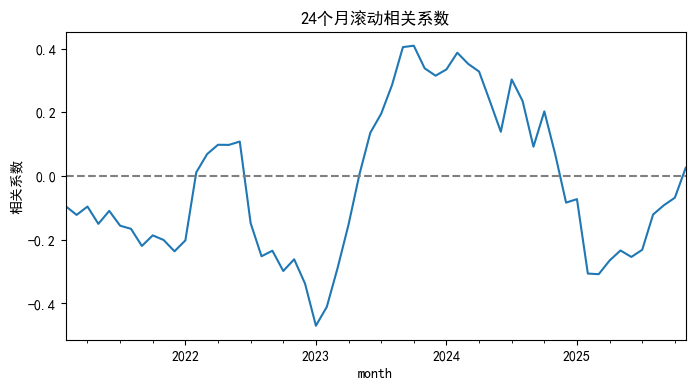

In [31]:
# -*- coding: utf-8 -*-
"""
时间序列精简版：教育文化娱乐 CPI vs 训练SnowNLP中心化
（已去掉 arch，仅保留平稳、协整、Granger、滚动相关）
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint, grangercausalitytests

# 1. 读数据
file_path = r'D:/NJU_WORKPIECE/期末：所有模型月度情感评分+经济指标.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1', index_col=0)
df.index = pd.to_datetime(df.index)

cpi_col = '居民消费价格指数(上年同月＝100)_当期'
sent_col = '训练snownlp中心化'
y1 = df[cpi_col].dropna()
y2 = df[sent_col].dropna()

common_idx = y1.index.intersection(y2.index)
y1, y2 = y1.loc[common_idx], y2.loc[common_idx]
print('样本期：', common_idx[0], '至', common_idx[-1], '共', len(common_idx), '个月')

# 2. 平稳性检验
def adf_test(sr, name):
    res = adfuller(sr, regression='ct')
    print(f'\n{name}  ADF={res[0]:.3f}, p={res[1]:.3f}')
    return res[1] < 0.05

y1_stationary = adf_test(y1, '居民消费价格指数')
y2_stationary = adf_test(y2, '训练SnowNLP中心化')

# 3. 协整
if not y1_stationary and not y2_stationary:
    eg_stat, eg_p, _ = coint(y1, y2, trend='ct')[:3]
    print(f'\nEngle-Granger 协整检验 stat={eg_stat:.3f}, p={eg_p:.3f}')
    cointegrated = eg_p < 0.05
else:
    cointegrated = False
    print('\n至少一个序列平稳，跳过协整检验')

# 4. Granger 因果
maxlag = 6
gc_res  = grangercausalitytests(pd.concat([y2, y1], axis=1), maxlag, verbose=False)
gpval   = gc_res[maxlag][0]['ssr_ftest'][1]      # 只取 p 值

gc_res2 = grangercausalitytests(pd.concat([y1, y2], axis=1), maxlag, verbose=False)
gpval2  = gc_res2[maxlag][0]['ssr_ftest'][1]

print(f'\n情绪→CPI  Granger p = {gpval:.3f}  {"拒绝" if gpval<0.05 else "不拒绝"}')
print(f'CPI→情绪  Granger p = {gpval2:.3f}  {"拒绝" if gpval2<0.05 else "不拒绝"}')

# 5. 滚动相关
window = 24
rolling_corr = y1.rolling(window).corr(y2).dropna()
plt.figure(figsize=(8, 4))
rolling_corr.plot(title=f'{window}个月滚动相关系数')
plt.axhline(0, color='grey', ls='--')
plt.ylabel('相关系数')
plt.show()

样本期： 2019-03-01 00:00:00 至 2025-11-01 00:00:00 共 81 个月

居民消费价格指数  ADF=-2.548, p=0.304

训练SnowNLP标题修正  ADF=-2.834, p=0.185

Engle-Granger 协整检验 stat=-2.032, p=0.758

情绪→CPI  Granger p = 0.914  不拒绝
CPI→情绪  Granger p = 0.648  不拒绝


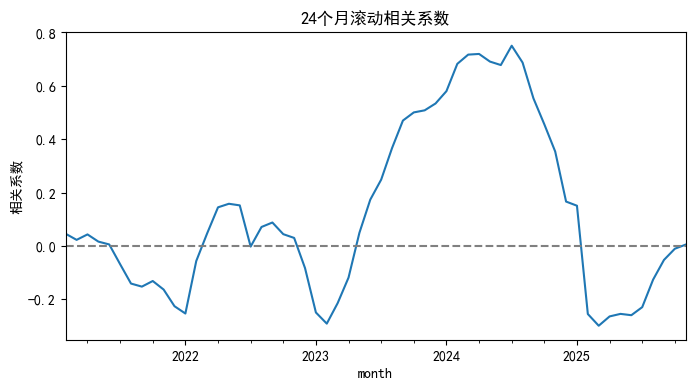

In [32]:
# -*- coding: utf-8 -*-
"""
时间序列精简版：教育文化娱乐 CPI vs 训练SnowNLP中心化
（已去掉 arch，仅保留平稳、协整、Granger、滚动相关）
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint, grangercausalitytests

# 1. 读数据
file_path = r'D:/NJU_WORKPIECE/期末：所有模型月度情感评分+经济指标.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1', index_col=0)
df.index = pd.to_datetime(df.index)

cpi_col = '居民消费价格指数(上年同月＝100)_当期'
sent_col = '训练snownlp标题修正'
y1 = df[cpi_col].dropna()
y2 = df[sent_col].dropna()

common_idx = y1.index.intersection(y2.index)
y1, y2 = y1.loc[common_idx], y2.loc[common_idx]
print('样本期：', common_idx[0], '至', common_idx[-1], '共', len(common_idx), '个月')

# 2. 平稳性检验
def adf_test(sr, name):
    res = adfuller(sr, regression='ct')
    print(f'\n{name}  ADF={res[0]:.3f}, p={res[1]:.3f}')
    return res[1] < 0.05

y1_stationary = adf_test(y1, '居民消费价格指数')
y2_stationary = adf_test(y2, '训练SnowNLP标题修正')

# 3. 协整
if not y1_stationary and not y2_stationary:
    eg_stat, eg_p, _ = coint(y1, y2, trend='ct')[:3]
    print(f'\nEngle-Granger 协整检验 stat={eg_stat:.3f}, p={eg_p:.3f}')
    cointegrated = eg_p < 0.05
else:
    cointegrated = False
    print('\n至少一个序列平稳，跳过协整检验')

# 4. Granger 因果
maxlag = 6
gc_res  = grangercausalitytests(pd.concat([y2, y1], axis=1), maxlag, verbose=False)
gpval   = gc_res[maxlag][0]['ssr_ftest'][1]      # 只取 p 值

gc_res2 = grangercausalitytests(pd.concat([y1, y2], axis=1), maxlag, verbose=False)
gpval2  = gc_res2[maxlag][0]['ssr_ftest'][1]

print(f'\n情绪→CPI  Granger p = {gpval:.3f}  {"拒绝" if gpval<0.05 else "不拒绝"}')
print(f'CPI→情绪  Granger p = {gpval2:.3f}  {"拒绝" if gpval2<0.05 else "不拒绝"}')

# 5. 滚动相关
window = 24
rolling_corr = y1.rolling(window).corr(y2).dropna()
plt.figure(figsize=(8, 4))
rolling_corr.plot(title=f'{window}个月滚动相关系数')
plt.axhline(0, color='grey', ls='--')
plt.ylabel('相关系数')
plt.show()

样本期： 2019-03-01 00:00:00 至 2025-11-01 00:00:00 共 81 个月

居民消费价格指数  ADF=-2.548, p=0.304

SnowNLP原始得分  ADF=-9.093, p=0.000

至少一个序列平稳，跳过协整检验

情绪→CPI  Granger p = 0.561  不拒绝
CPI→情绪  Granger p = 0.859  不拒绝


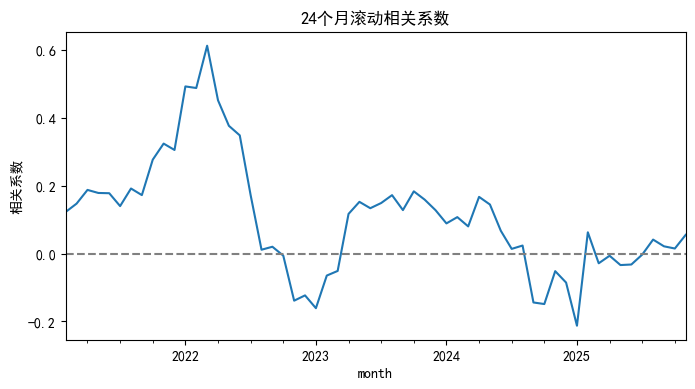

In [33]:
# -*- coding: utf-8 -*-
"""
时间序列精简版：教育文化娱乐 CPI vs 训练SnowNLP中心化
（已去掉 arch，仅保留平稳、协整、Granger、滚动相关）
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint, grangercausalitytests

# 1. 读数据
file_path = r'D:/NJU_WORKPIECE/期末：所有模型月度情感评分+经济指标.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1', index_col=0)
df.index = pd.to_datetime(df.index)

cpi_col = '居民消费价格指数(上年同月＝100)_当期'
sent_col = 'snownlp原始得分'
y1 = df[cpi_col].dropna()
y2 = df[sent_col].dropna()

common_idx = y1.index.intersection(y2.index)
y1, y2 = y1.loc[common_idx], y2.loc[common_idx]
print('样本期：', common_idx[0], '至', common_idx[-1], '共', len(common_idx), '个月')

# 2. 平稳性检验
def adf_test(sr, name):
    res = adfuller(sr, regression='ct')
    print(f'\n{name}  ADF={res[0]:.3f}, p={res[1]:.3f}')
    return res[1] < 0.05

y1_stationary = adf_test(y1, '居民消费价格指数')
y2_stationary = adf_test(y2, 'SnowNLP原始得分')

# 3. 协整
if not y1_stationary and not y2_stationary:
    eg_stat, eg_p, _ = coint(y1, y2, trend='ct')[:3]
    print(f'\nEngle-Granger 协整检验 stat={eg_stat:.3f}, p={eg_p:.3f}')
    cointegrated = eg_p < 0.05
else:
    cointegrated = False
    print('\n至少一个序列平稳，跳过协整检验')

# 4. Granger 因果
maxlag = 6
gc_res  = grangercausalitytests(pd.concat([y2, y1], axis=1), maxlag, verbose=False)
gpval   = gc_res[maxlag][0]['ssr_ftest'][1]      # 只取 p 值

gc_res2 = grangercausalitytests(pd.concat([y1, y2], axis=1), maxlag, verbose=False)
gpval2  = gc_res2[maxlag][0]['ssr_ftest'][1]

print(f'\n情绪→CPI  Granger p = {gpval:.3f}  {"拒绝" if gpval<0.05 else "不拒绝"}')
print(f'CPI→情绪  Granger p = {gpval2:.3f}  {"拒绝" if gpval2<0.05 else "不拒绝"}')

# 5. 滚动相关
window = 24
rolling_corr = y1.rolling(window).corr(y2).dropna()
plt.figure(figsize=(8, 4))
rolling_corr.plot(title=f'{window}个月滚动相关系数')
plt.axhline(0, color='grey', ls='--')
plt.ylabel('相关系数')
plt.show()

样本期： 2019-03-01 00:00:00 至 2025-11-01 00:00:00 共 81 个月

居民消费价格指数  ADF=-2.548, p=0.304

svm原始得分  ADF=-5.299, p=0.000

至少一个序列平稳，跳过协整检验

情绪→CPI  Granger p = 0.637  不拒绝
CPI→情绪  Granger p = 0.204  不拒绝


C:\Anaconda\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


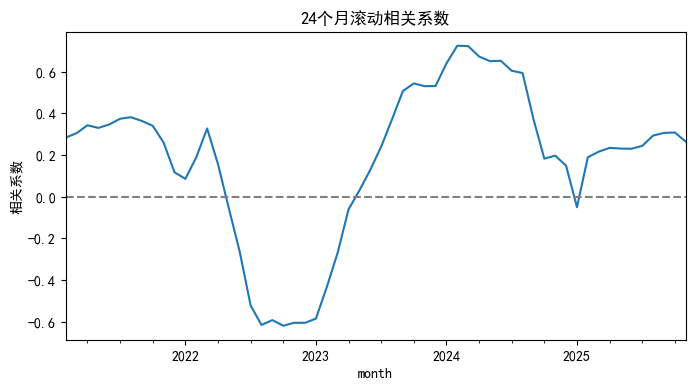

In [1]:
# -*- coding: utf-8 -*-
"""
时间序列精简版：教育文化娱乐 CPI vs 训练SnowNLP中心化
（已去掉 arch，仅保留平稳、协整、Granger、滚动相关）
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint, grangercausalitytests

# 1. 读数据
file_path = r'D:/NJU_WORKPIECE/期末：所有模型月度情感评分+经济指标.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1', index_col=0)
df.index = pd.to_datetime(df.index)

cpi_col = '居民消费价格指数(上年同月＝100)_当期'
sent_col = 'svm原始得分'
y1 = df[cpi_col].dropna()
y2 = df[sent_col].dropna()

common_idx = y1.index.intersection(y2.index)
y1, y2 = y1.loc[common_idx], y2.loc[common_idx]
print('样本期：', common_idx[0], '至', common_idx[-1], '共', len(common_idx), '个月')

# 2. 平稳性检验
def adf_test(sr, name):
    res = adfuller(sr, regression='ct')
    print(f'\n{name}  ADF={res[0]:.3f}, p={res[1]:.3f}')
    return res[1] < 0.05

y1_stationary = adf_test(y1, '居民消费价格指数')
y2_stationary = adf_test(y2, 'svm原始得分')

# 3. 协整
if not y1_stationary and not y2_stationary:
    eg_stat, eg_p, _ = coint(y1, y2, trend='ct')[:3]
    print(f'\nEngle-Granger 协整检验 stat={eg_stat:.3f}, p={eg_p:.3f}')
    cointegrated = eg_p < 0.05
else:
    cointegrated = False
    print('\n至少一个序列平稳，跳过协整检验')

# 4. Granger 因果
maxlag = 6
gc_res  = grangercausalitytests(pd.concat([y2, y1], axis=1), maxlag, verbose=False)
gpval   = gc_res[maxlag][0]['ssr_ftest'][1]      # 只取 p 值

gc_res2 = grangercausalitytests(pd.concat([y1, y2], axis=1), maxlag, verbose=False)
gpval2  = gc_res2[maxlag][0]['ssr_ftest'][1]

print(f'\n情绪→CPI  Granger p = {gpval:.3f}  {"拒绝" if gpval<0.05 else "不拒绝"}')
print(f'CPI→情绪  Granger p = {gpval2:.3f}  {"拒绝" if gpval2<0.05 else "不拒绝"}')

# 5. 滚动相关
window = 24
rolling_corr = y1.rolling(window).corr(y2).dropna()
plt.figure(figsize=(8, 4))
rolling_corr.plot(title=f'{window}个月滚动相关系数')
plt.axhline(0, color='grey', ls='--')
plt.ylabel('相关系数')
plt.show()

样本期： 2019-03-01 00:00:00 至 2025-11-01 00:00:00 共 81 个月

居民消费价格指数  ADF=-2.548, p=0.304

svm中心化  ADF=-7.522, p=0.000

至少一个序列平稳，跳过协整检验

情绪→CPI  Granger p = 0.705  不拒绝
CPI→情绪  Granger p = 0.136  不拒绝


C:\Anaconda\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


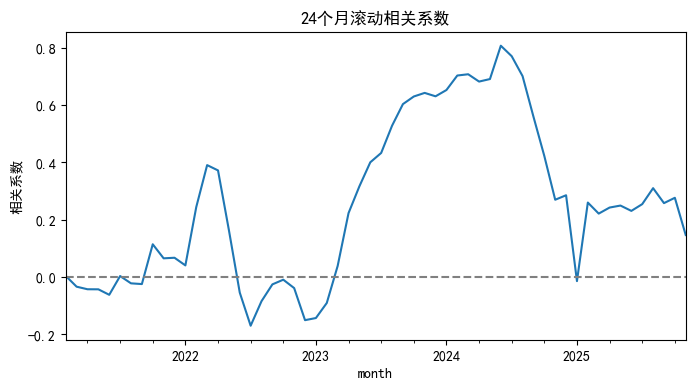

In [2]:
# -*- coding: utf-8 -*-
"""
时间序列精简版：教育文化娱乐 CPI vs 训练SnowNLP中心化
（已去掉 arch，仅保留平稳、协整、Granger、滚动相关）
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint, grangercausalitytests

# 1. 读数据
file_path = r'D:/NJU_WORKPIECE/期末：所有模型月度情感评分+经济指标.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1', index_col=0)
df.index = pd.to_datetime(df.index)

cpi_col = '居民消费价格指数(上年同月＝100)_当期'
sent_col = 'svm中心化'
y1 = df[cpi_col].dropna()
y2 = df[sent_col].dropna()

common_idx = y1.index.intersection(y2.index)
y1, y2 = y1.loc[common_idx], y2.loc[common_idx]
print('样本期：', common_idx[0], '至', common_idx[-1], '共', len(common_idx), '个月')

# 2. 平稳性检验
def adf_test(sr, name):
    res = adfuller(sr, regression='ct')
    print(f'\n{name}  ADF={res[0]:.3f}, p={res[1]:.3f}')
    return res[1] < 0.05

y1_stationary = adf_test(y1, '居民消费价格指数')
y2_stationary = adf_test(y2, 'svm中心化')

# 3. 协整
if not y1_stationary and not y2_stationary:
    eg_stat, eg_p, _ = coint(y1, y2, trend='ct')[:3]
    print(f'\nEngle-Granger 协整检验 stat={eg_stat:.3f}, p={eg_p:.3f}')
    cointegrated = eg_p < 0.05
else:
    cointegrated = False
    print('\n至少一个序列平稳，跳过协整检验')

# 4. Granger 因果
maxlag = 6
gc_res  = grangercausalitytests(pd.concat([y2, y1], axis=1), maxlag, verbose=False)
gpval   = gc_res[maxlag][0]['ssr_ftest'][1]      # 只取 p 值

gc_res2 = grangercausalitytests(pd.concat([y1, y2], axis=1), maxlag, verbose=False)
gpval2  = gc_res2[maxlag][0]['ssr_ftest'][1]

print(f'\n情绪→CPI  Granger p = {gpval:.3f}  {"拒绝" if gpval<0.05 else "不拒绝"}')
print(f'CPI→情绪  Granger p = {gpval2:.3f}  {"拒绝" if gpval2<0.05 else "不拒绝"}')

# 5. 滚动相关
window = 24
rolling_corr = y1.rolling(window).corr(y2).dropna()
plt.figure(figsize=(8, 4))
rolling_corr.plot(title=f'{window}个月滚动相关系数')
plt.axhline(0, color='grey', ls='--')
plt.ylabel('相关系数')
plt.show()

样本期： 2019-03-01 00:00:00 至 2025-11-01 00:00:00 共 81 个月

居民消费价格指数  ADF=-2.548, p=0.304

svm标题修正  ADF=-6.177, p=0.000

至少一个序列平稳，跳过协整检验

情绪→CPI  Granger p = 0.892  不拒绝
CPI→情绪  Granger p = 0.056  不拒绝


C:\Anaconda\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


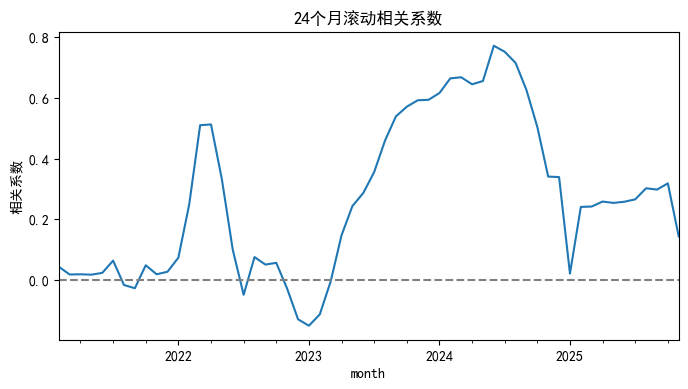

In [3]:
# -*- coding: utf-8 -*-
"""
时间序列精简版：教育文化娱乐 CPI vs 训练SnowNLP中心化
（已去掉 arch，仅保留平稳、协整、Granger、滚动相关）
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint, grangercausalitytests

# 1. 读数据
file_path = r'D:/NJU_WORKPIECE/期末：所有模型月度情感评分+经济指标.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1', index_col=0)
df.index = pd.to_datetime(df.index)

cpi_col = '居民消费价格指数(上年同月＝100)_当期'
sent_col = 'svm标题修正'
y1 = df[cpi_col].dropna()
y2 = df[sent_col].dropna()

common_idx = y1.index.intersection(y2.index)
y1, y2 = y1.loc[common_idx], y2.loc[common_idx]
print('样本期：', common_idx[0], '至', common_idx[-1], '共', len(common_idx), '个月')

# 2. 平稳性检验
def adf_test(sr, name):
    res = adfuller(sr, regression='ct')
    print(f'\n{name}  ADF={res[0]:.3f}, p={res[1]:.3f}')
    return res[1] < 0.05

y1_stationary = adf_test(y1, '居民消费价格指数')
y2_stationary = adf_test(y2, 'svm标题修正')

# 3. 协整
if not y1_stationary and not y2_stationary:
    eg_stat, eg_p, _ = coint(y1, y2, trend='ct')[:3]
    print(f'\nEngle-Granger 协整检验 stat={eg_stat:.3f}, p={eg_p:.3f}')
    cointegrated = eg_p < 0.05
else:
    cointegrated = False
    print('\n至少一个序列平稳，跳过协整检验')

# 4. Granger 因果
maxlag = 6
gc_res  = grangercausalitytests(pd.concat([y2, y1], axis=1), maxlag, verbose=False)
gpval   = gc_res[maxlag][0]['ssr_ftest'][1]      # 只取 p 值

gc_res2 = grangercausalitytests(pd.concat([y1, y2], axis=1), maxlag, verbose=False)
gpval2  = gc_res2[maxlag][0]['ssr_ftest'][1]

print(f'\n情绪→CPI  Granger p = {gpval:.3f}  {"拒绝" if gpval<0.05 else "不拒绝"}')
print(f'CPI→情绪  Granger p = {gpval2:.3f}  {"拒绝" if gpval2<0.05 else "不拒绝"}')

# 5. 滚动相关
window = 24
rolling_corr = y1.rolling(window).corr(y2).dropna()
plt.figure(figsize=(8, 4))
rolling_corr.plot(title=f'{window}个月滚动相关系数')
plt.axhline(0, color='grey', ls='--')
plt.ylabel('相关系数')
plt.show()

样本期： 2019-03-01 00:00:00 至 2025-11-01 00:00:00 共 81 个月

居民消费价格指数  ADF=-2.548, p=0.304

nb原始得分  ADF=-1.717, p=0.743

Engle-Granger 协整检验 stat=-2.762, p=0.378

情绪→CPI  Granger p = 0.830  不拒绝
CPI→情绪  Granger p = 0.223  不拒绝


C:\Anaconda\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


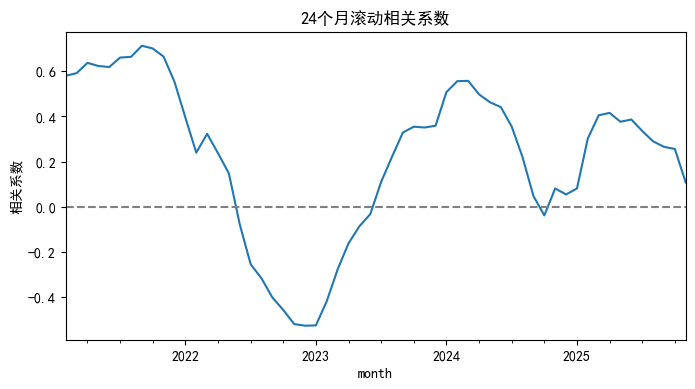

In [4]:
# -*- coding: utf-8 -*-
"""
时间序列精简版：教育文化娱乐 CPI vs 训练SnowNLP中心化
（已去掉 arch，仅保留平稳、协整、Granger、滚动相关）
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint, grangercausalitytests

# 1. 读数据
file_path = r'D:/NJU_WORKPIECE/期末：所有模型月度情感评分+经济指标.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1', index_col=0)
df.index = pd.to_datetime(df.index)

cpi_col = '居民消费价格指数(上年同月＝100)_当期'
sent_col = 'nb原始得分'
y1 = df[cpi_col].dropna()
y2 = df[sent_col].dropna()

common_idx = y1.index.intersection(y2.index)
y1, y2 = y1.loc[common_idx], y2.loc[common_idx]
print('样本期：', common_idx[0], '至', common_idx[-1], '共', len(common_idx), '个月')

# 2. 平稳性检验
def adf_test(sr, name):
    res = adfuller(sr, regression='ct')
    print(f'\n{name}  ADF={res[0]:.3f}, p={res[1]:.3f}')
    return res[1] < 0.05

y1_stationary = adf_test(y1, '居民消费价格指数')
y2_stationary = adf_test(y2, 'nb原始得分')

# 3. 协整
if not y1_stationary and not y2_stationary:
    eg_stat, eg_p, _ = coint(y1, y2, trend='ct')[:3]
    print(f'\nEngle-Granger 协整检验 stat={eg_stat:.3f}, p={eg_p:.3f}')
    cointegrated = eg_p < 0.05
else:
    cointegrated = False
    print('\n至少一个序列平稳，跳过协整检验')

# 4. Granger 因果
maxlag = 6
gc_res  = grangercausalitytests(pd.concat([y2, y1], axis=1), maxlag, verbose=False)
gpval   = gc_res[maxlag][0]['ssr_ftest'][1]      # 只取 p 值

gc_res2 = grangercausalitytests(pd.concat([y1, y2], axis=1), maxlag, verbose=False)
gpval2  = gc_res2[maxlag][0]['ssr_ftest'][1]

print(f'\n情绪→CPI  Granger p = {gpval:.3f}  {"拒绝" if gpval<0.05 else "不拒绝"}')
print(f'CPI→情绪  Granger p = {gpval2:.3f}  {"拒绝" if gpval2<0.05 else "不拒绝"}')

# 5. 滚动相关
window = 24
rolling_corr = y1.rolling(window).corr(y2).dropna()
plt.figure(figsize=(8, 4))
rolling_corr.plot(title=f'{window}个月滚动相关系数')
plt.axhline(0, color='grey', ls='--')
plt.ylabel('相关系数')
plt.show()

In [9]:
#nb中心化有效

样本期： 2019-03-01 00:00:00 至 2025-11-01 00:00:00 共 81 个月

居民消费价格指数  ADF=-2.548, p=0.304

nb中心化  ADF=-1.132, p=0.923

Engle-Granger 协整检验 stat=-2.357, p=0.599

情绪→CPI  Granger p = 0.693  不拒绝
CPI→情绪  Granger p = 0.044  拒绝


C:\Anaconda\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


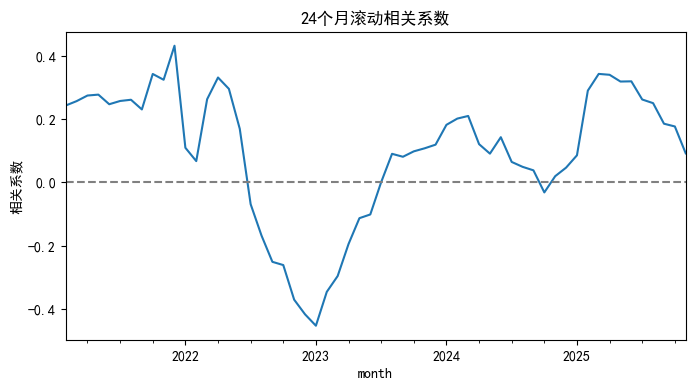

In [8]:
# -*- coding: utf-8 -*-
"""
时间序列精简版：教育文化娱乐 CPI vs 训练SnowNLP中心化
（已去掉 arch，仅保留平稳、协整、Granger、滚动相关）
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint, grangercausalitytests

# 1. 读数据
file_path = r'D:/NJU_WORKPIECE/期末：所有模型月度情感评分+经济指标.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1', index_col=0)
df.index = pd.to_datetime(df.index)

cpi_col = '居民消费价格指数(上年同月＝100)_当期'
sent_col = 'nb中心化'
y1 = df[cpi_col].dropna()
y2 = df[sent_col].dropna()

common_idx = y1.index.intersection(y2.index)
y1, y2 = y1.loc[common_idx], y2.loc[common_idx]
print('样本期：', common_idx[0], '至', common_idx[-1], '共', len(common_idx), '个月')

# 2. 平稳性检验
def adf_test(sr, name):
    res = adfuller(sr, regression='ct')
    print(f'\n{name}  ADF={res[0]:.3f}, p={res[1]:.3f}')
    return res[1] < 0.05

y1_stationary = adf_test(y1, '居民消费价格指数')
y2_stationary = adf_test(y2, 'nb中心化')

# 3. 协整
if not y1_stationary and not y2_stationary:
    eg_stat, eg_p, _ = coint(y1, y2, trend='ct')[:3]
    print(f'\nEngle-Granger 协整检验 stat={eg_stat:.3f}, p={eg_p:.3f}')
    cointegrated = eg_p < 0.05
else:
    cointegrated = False
    print('\n至少一个序列平稳，跳过协整检验')

# 4. Granger 因果
maxlag = 6
gc_res  = grangercausalitytests(pd.concat([y2, y1], axis=1), maxlag, verbose=False)
gpval   = gc_res[maxlag][0]['ssr_ftest'][1]      # 只取 p 值

gc_res2 = grangercausalitytests(pd.concat([y1, y2], axis=1), maxlag, verbose=False)
gpval2  = gc_res2[maxlag][0]['ssr_ftest'][1]

print(f'\n情绪→CPI  Granger p = {gpval:.3f}  {"拒绝" if gpval<0.05 else "不拒绝"}')
print(f'CPI→情绪  Granger p = {gpval2:.3f}  {"拒绝" if gpval2<0.05 else "不拒绝"}')

# 5. 滚动相关
window = 24
rolling_corr = y1.rolling(window).corr(y2).dropna()
plt.figure(figsize=(8, 4))
rolling_corr.plot(title=f'{window}个月滚动相关系数')
plt.axhline(0, color='grey', ls='--')
plt.ylabel('相关系数')
plt.show()

样本期： 2019-03-01 00:00:00 至 2025-11-01 00:00:00 共 81 个月

居民消费价格指数  ADF=-2.548, p=0.304

nb标题修正  ADF=-5.723, p=0.000

至少一个序列平稳，跳过协整检验

情绪→CPI  Granger p = 0.519  不拒绝
CPI→情绪  Granger p = 0.098  不拒绝


C:\Anaconda\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


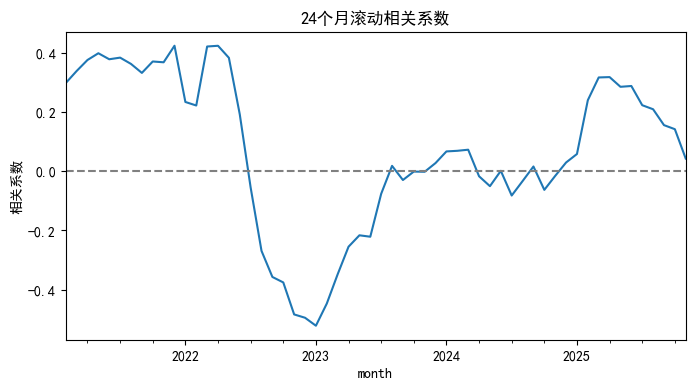

In [7]:
# -*- coding: utf-8 -*-
"""
时间序列精简版：教育文化娱乐 CPI vs 训练SnowNLP中心化
（已去掉 arch，仅保留平稳、协整、Granger、滚动相关）
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint, grangercausalitytests

# 1. 读数据
file_path = r'D:/NJU_WORKPIECE/期末：所有模型月度情感评分+经济指标.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1', index_col=0)
df.index = pd.to_datetime(df.index)

cpi_col = '居民消费价格指数(上年同月＝100)_当期'
sent_col = 'nb标题修正'
y1 = df[cpi_col].dropna()
y2 = df[sent_col].dropna()

common_idx = y1.index.intersection(y2.index)
y1, y2 = y1.loc[common_idx], y2.loc[common_idx]
print('样本期：', common_idx[0], '至', common_idx[-1], '共', len(common_idx), '个月')

# 2. 平稳性检验
def adf_test(sr, name):
    res = adfuller(sr, regression='ct')
    print(f'\n{name}  ADF={res[0]:.3f}, p={res[1]:.3f}')
    return res[1] < 0.05

y1_stationary = adf_test(y1, '居民消费价格指数')
y2_stationary = adf_test(y2, 'nb标题修正')

# 3. 协整
if not y1_stationary and not y2_stationary:
    eg_stat, eg_p, _ = coint(y1, y2, trend='ct')[:3]
    print(f'\nEngle-Granger 协整检验 stat={eg_stat:.3f}, p={eg_p:.3f}')
    cointegrated = eg_p < 0.05
else:
    cointegrated = False
    print('\n至少一个序列平稳，跳过协整检验')

# 4. Granger 因果
maxlag = 6
gc_res  = grangercausalitytests(pd.concat([y2, y1], axis=1), maxlag, verbose=False)
gpval   = gc_res[maxlag][0]['ssr_ftest'][1]      # 只取 p 值

gc_res2 = grangercausalitytests(pd.concat([y1, y2], axis=1), maxlag, verbose=False)
gpval2  = gc_res2[maxlag][0]['ssr_ftest'][1]

print(f'\n情绪→CPI  Granger p = {gpval:.3f}  {"拒绝" if gpval<0.05 else "不拒绝"}')
print(f'CPI→情绪  Granger p = {gpval2:.3f}  {"拒绝" if gpval2<0.05 else "不拒绝"}')

# 5. 滚动相关
window = 24
rolling_corr = y1.rolling(window).corr(y2).dropna()
plt.figure(figsize=(8, 4))
rolling_corr.plot(title=f'{window}个月滚动相关系数')
plt.axhline(0, color='grey', ls='--')
plt.ylabel('相关系数')
plt.show()

样本期： 2019-03-01 00:00:00 至 2025-11-01 00:00:00 共 81 个月

教育文化娱乐CPI  ADF=-1.912, p=0.649

svm标题修正  ADF=-6.177, p=0.000

至少一个序列平稳，跳过协整检验

情绪→CPI  Granger p = 0.717  不拒绝
CPI→情绪  Granger p = 0.208  不拒绝


C:\Anaconda\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


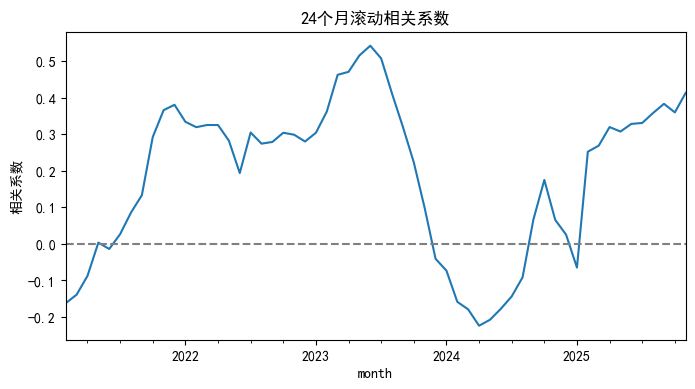

In [10]:
# -*- coding: utf-8 -*-
"""
时间序列精简版：教育文化娱乐 CPI vs 训练SnowNLP中心化
（已去掉 arch，仅保留平稳、协整、Granger、滚动相关）
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint, grangercausalitytests

# 1. 读数据
file_path = r'D:/NJU_WORKPIECE/期末：所有模型月度情感评分+经济指标.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1', index_col=0)
df.index = pd.to_datetime(df.index)

cpi_col = '居民消费价格指数(上年同月＝100)_教育文化娱乐_当期'
sent_col = 'svm标题修正'
y1 = df[cpi_col].dropna()
y2 = df[sent_col].dropna()

common_idx = y1.index.intersection(y2.index)
y1, y2 = y1.loc[common_idx], y2.loc[common_idx]
print('样本期：', common_idx[0], '至', common_idx[-1], '共', len(common_idx), '个月')

# 2. 平稳性检验
def adf_test(sr, name):
    res = adfuller(sr, regression='ct')
    print(f'\n{name}  ADF={res[0]:.3f}, p={res[1]:.3f}')
    return res[1] < 0.05

y1_stationary = adf_test(y1, '教育文化娱乐CPI')
y2_stationary = adf_test(y2, 'svm标题修正')

# 3. 协整
if not y1_stationary and not y2_stationary:
    eg_stat, eg_p, _ = coint(y1, y2, trend='ct')[:3]
    print(f'\nEngle-Granger 协整检验 stat={eg_stat:.3f}, p={eg_p:.3f}')
    cointegrated = eg_p < 0.05
else:
    cointegrated = False
    print('\n至少一个序列平稳，跳过协整检验')


# 4. Granger 因果
maxlag = 6
gc_res  = grangercausalitytests(pd.concat([y2, y1], axis=1), maxlag, verbose=False)
gpval   = gc_res[maxlag][0]['ssr_ftest'][1]      # 只取 p 值

gc_res2 = grangercausalitytests(pd.concat([y1, y2], axis=1), maxlag, verbose=False)
gpval2  = gc_res2[maxlag][0]['ssr_ftest'][1]

print(f'\n情绪→CPI  Granger p = {gpval:.3f}  {"拒绝" if gpval<0.05 else "不拒绝"}')
print(f'CPI→情绪  Granger p = {gpval2:.3f}  {"拒绝" if gpval2<0.05 else "不拒绝"}')

# 5. 滚动相关
window = 24
rolling_corr = y1.rolling(window).corr(y2).dropna()
plt.figure(figsize=(8, 4))
rolling_corr.plot(title=f'{window}个月滚动相关系数')
plt.axhline(0, color='grey', ls='--')
plt.ylabel('相关系数')
plt.show()

样本期： 2019-03-01 00:00:00 至 2025-11-01 00:00:00 共 81 个月

教育文化娱乐CPI  ADF=-1.912, p=0.649

svm原始得分  ADF=-5.299, p=0.000

至少一个序列平稳，跳过协整检验

情绪→CPI  Granger p = 0.285  不拒绝
CPI→情绪  Granger p = 0.662  不拒绝


C:\Anaconda\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


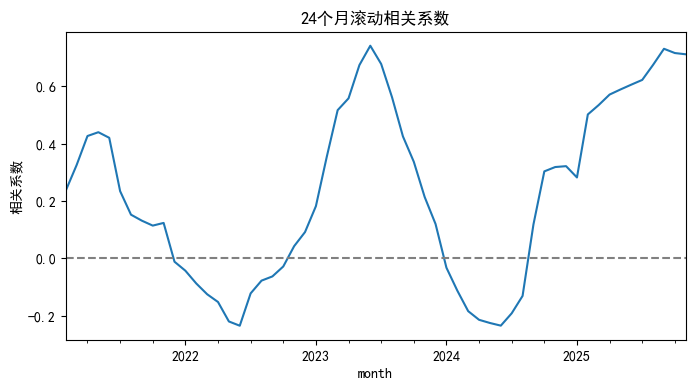

In [11]:
# -*- coding: utf-8 -*-
"""
时间序列精简版：教育文化娱乐 CPI vs 训练SnowNLP中心化
（已去掉 arch，仅保留平稳、协整、Granger、滚动相关）
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint, grangercausalitytests

# 1. 读数据
file_path = r'D:/NJU_WORKPIECE/期末：所有模型月度情感评分+经济指标.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1', index_col=0)
df.index = pd.to_datetime(df.index)

cpi_col = '居民消费价格指数(上年同月＝100)_教育文化娱乐_当期'
sent_col = 'svm原始得分'
y1 = df[cpi_col].dropna()
y2 = df[sent_col].dropna()

common_idx = y1.index.intersection(y2.index)
y1, y2 = y1.loc[common_idx], y2.loc[common_idx]
print('样本期：', common_idx[0], '至', common_idx[-1], '共', len(common_idx), '个月')

# 2. 平稳性检验
def adf_test(sr, name):
    res = adfuller(sr, regression='ct')
    print(f'\n{name}  ADF={res[0]:.3f}, p={res[1]:.3f}')
    return res[1] < 0.05

y1_stationary = adf_test(y1, '教育文化娱乐CPI')
y2_stationary = adf_test(y2, 'svm原始得分')

# 3. 协整
if not y1_stationary and not y2_stationary:
    eg_stat, eg_p, _ = coint(y1, y2, trend='ct')[:3]
    print(f'\nEngle-Granger 协整检验 stat={eg_stat:.3f}, p={eg_p:.3f}')
    cointegrated = eg_p < 0.05
else:
    cointegrated = False
    print('\n至少一个序列平稳，跳过协整检验')


# 4. Granger 因果
maxlag = 6
gc_res  = grangercausalitytests(pd.concat([y2, y1], axis=1), maxlag, verbose=False)
gpval   = gc_res[maxlag][0]['ssr_ftest'][1]      # 只取 p 值

gc_res2 = grangercausalitytests(pd.concat([y1, y2], axis=1), maxlag, verbose=False)
gpval2  = gc_res2[maxlag][0]['ssr_ftest'][1]

print(f'\n情绪→CPI  Granger p = {gpval:.3f}  {"拒绝" if gpval<0.05 else "不拒绝"}')
print(f'CPI→情绪  Granger p = {gpval2:.3f}  {"拒绝" if gpval2<0.05 else "不拒绝"}')

# 5. 滚动相关
window = 24
rolling_corr = y1.rolling(window).corr(y2).dropna()
plt.figure(figsize=(8, 4))
rolling_corr.plot(title=f'{window}个月滚动相关系数')
plt.axhline(0, color='grey', ls='--')
plt.ylabel('相关系数')
plt.show()

样本期： 2019-03-01 00:00:00 至 2025-11-01 00:00:00 共 81 个月

教育文化娱乐CPI  ADF=-1.912, p=0.649

svm中心化  ADF=-7.522, p=0.000

至少一个序列平稳，跳过协整检验

情绪→CPI  Granger p = 0.748  不拒绝
CPI→情绪  Granger p = 0.216  不拒绝


C:\Anaconda\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


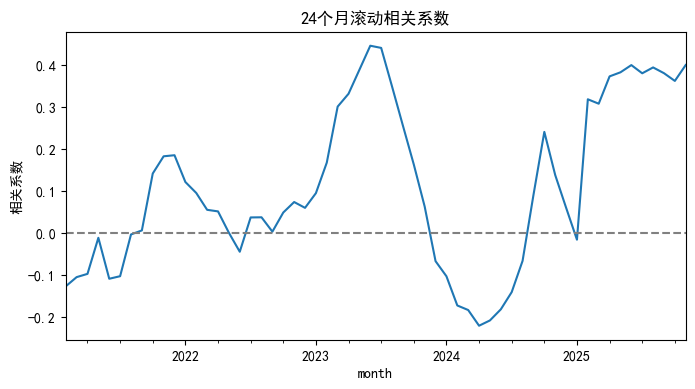

In [12]:
# -*- coding: utf-8 -*-
"""
时间序列精简版：教育文化娱乐 CPI vs 训练SnowNLP中心化
（已去掉 arch，仅保留平稳、协整、Granger、滚动相关）
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint, grangercausalitytests

# 1. 读数据
file_path = r'D:/NJU_WORKPIECE/期末：所有模型月度情感评分+经济指标.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1', index_col=0)
df.index = pd.to_datetime(df.index)

cpi_col = '居民消费价格指数(上年同月＝100)_教育文化娱乐_当期'
sent_col = 'svm中心化'
y1 = df[cpi_col].dropna()
y2 = df[sent_col].dropna()

common_idx = y1.index.intersection(y2.index)
y1, y2 = y1.loc[common_idx], y2.loc[common_idx]
print('样本期：', common_idx[0], '至', common_idx[-1], '共', len(common_idx), '个月')

# 2. 平稳性检验
def adf_test(sr, name):
    res = adfuller(sr, regression='ct')
    print(f'\n{name}  ADF={res[0]:.3f}, p={res[1]:.3f}')
    return res[1] < 0.05

y1_stationary = adf_test(y1, '教育文化娱乐CPI')
y2_stationary = adf_test(y2, 'svm中心化')

# 3. 协整
if not y1_stationary and not y2_stationary:
    eg_stat, eg_p, _ = coint(y1, y2, trend='ct')[:3]
    print(f'\nEngle-Granger 协整检验 stat={eg_stat:.3f}, p={eg_p:.3f}')
    cointegrated = eg_p < 0.05
else:
    cointegrated = False
    print('\n至少一个序列平稳，跳过协整检验')


# 4. Granger 因果
maxlag = 6
gc_res  = grangercausalitytests(pd.concat([y2, y1], axis=1), maxlag, verbose=False)
gpval   = gc_res[maxlag][0]['ssr_ftest'][1]      # 只取 p 值

gc_res2 = grangercausalitytests(pd.concat([y1, y2], axis=1), maxlag, verbose=False)
gpval2  = gc_res2[maxlag][0]['ssr_ftest'][1]

print(f'\n情绪→CPI  Granger p = {gpval:.3f}  {"拒绝" if gpval<0.05 else "不拒绝"}')
print(f'CPI→情绪  Granger p = {gpval2:.3f}  {"拒绝" if gpval2<0.05 else "不拒绝"}')

# 5. 滚动相关
window = 24
rolling_corr = y1.rolling(window).corr(y2).dropna()
plt.figure(figsize=(8, 4))
rolling_corr.plot(title=f'{window}个月滚动相关系数')
plt.axhline(0, color='grey', ls='--')
plt.ylabel('相关系数')
plt.show()

样本期： 2019-03-01 00:00:00 至 2025-11-01 00:00:00 共 81 个月

教育文化娱乐CPI  ADF=-1.912, p=0.649

nb标题修正  ADF=-5.723, p=0.000

至少一个序列平稳，跳过协整检验

情绪→CPI  Granger p = 0.201  不拒绝
CPI→情绪  Granger p = 0.786  不拒绝


C:\Anaconda\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


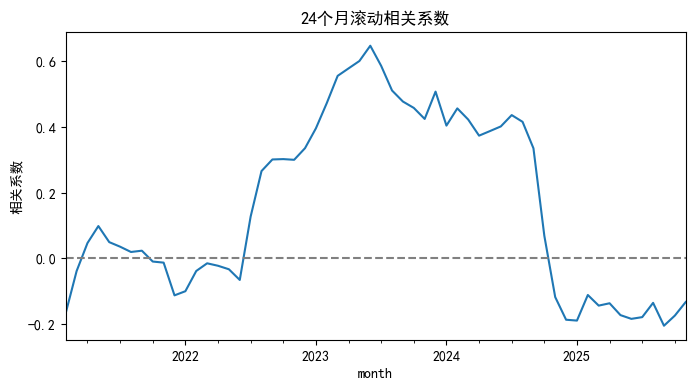

In [13]:
# -*- coding: utf-8 -*-
"""
时间序列精简版：教育文化娱乐 CPI vs 训练SnowNLP中心化
（已去掉 arch，仅保留平稳、协整、Granger、滚动相关）
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint, grangercausalitytests

# 1. 读数据
file_path = r'D:/NJU_WORKPIECE/期末：所有模型月度情感评分+经济指标.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1', index_col=0)
df.index = pd.to_datetime(df.index)

cpi_col = '居民消费价格指数(上年同月＝100)_教育文化娱乐_当期'
sent_col = 'nb标题修正'
y1 = df[cpi_col].dropna()
y2 = df[sent_col].dropna()

common_idx = y1.index.intersection(y2.index)
y1, y2 = y1.loc[common_idx], y2.loc[common_idx]
print('样本期：', common_idx[0], '至', common_idx[-1], '共', len(common_idx), '个月')

# 2. 平稳性检验
def adf_test(sr, name):
    res = adfuller(sr, regression='ct')
    print(f'\n{name}  ADF={res[0]:.3f}, p={res[1]:.3f}')
    return res[1] < 0.05

y1_stationary = adf_test(y1, '教育文化娱乐CPI')
y2_stationary = adf_test(y2, 'nb标题修正')

# 3. 协整
if not y1_stationary and not y2_stationary:
    eg_stat, eg_p, _ = coint(y1, y2, trend='ct')[:3]
    print(f'\nEngle-Granger 协整检验 stat={eg_stat:.3f}, p={eg_p:.3f}')
    cointegrated = eg_p < 0.05
else:
    cointegrated = False
    print('\n至少一个序列平稳，跳过协整检验')


# 4. Granger 因果
maxlag = 6
gc_res  = grangercausalitytests(pd.concat([y2, y1], axis=1), maxlag, verbose=False)
gpval   = gc_res[maxlag][0]['ssr_ftest'][1]      # 只取 p 值

gc_res2 = grangercausalitytests(pd.concat([y1, y2], axis=1), maxlag, verbose=False)
gpval2  = gc_res2[maxlag][0]['ssr_ftest'][1]

print(f'\n情绪→CPI  Granger p = {gpval:.3f}  {"拒绝" if gpval<0.05 else "不拒绝"}')
print(f'CPI→情绪  Granger p = {gpval2:.3f}  {"拒绝" if gpval2<0.05 else "不拒绝"}')

# 5. 滚动相关
window = 24
rolling_corr = y1.rolling(window).corr(y2).dropna()
plt.figure(figsize=(8, 4))
rolling_corr.plot(title=f'{window}个月滚动相关系数')
plt.axhline(0, color='grey', ls='--')
plt.ylabel('相关系数')
plt.show()

样本期： 2019-03-01 00:00:00 至 2025-11-01 00:00:00 共 81 个月

教育文化娱乐CPI  ADF=-1.912, p=0.649

nb原始得分  ADF=-1.717, p=0.743

Engle-Granger 协整检验 stat=-2.095, p=0.730

情绪→CPI  Granger p = 0.860  不拒绝
CPI→情绪  Granger p = 0.794  不拒绝


C:\Anaconda\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


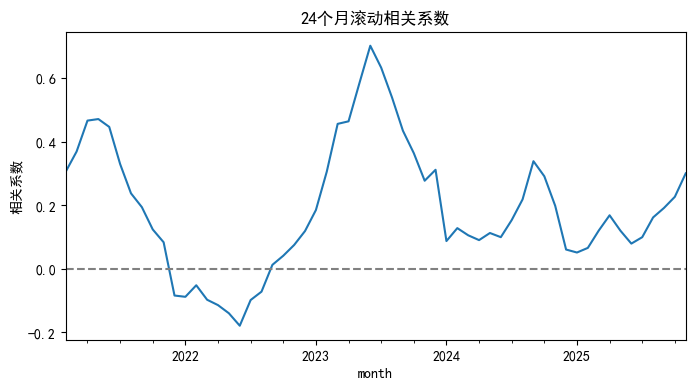

In [14]:
# -*- coding: utf-8 -*-
"""
时间序列精简版：教育文化娱乐 CPI vs 训练SnowNLP中心化
（已去掉 arch，仅保留平稳、协整、Granger、滚动相关）
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint, grangercausalitytests

# 1. 读数据
file_path = r'D:/NJU_WORKPIECE/期末：所有模型月度情感评分+经济指标.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1', index_col=0)
df.index = pd.to_datetime(df.index)

cpi_col = '居民消费价格指数(上年同月＝100)_教育文化娱乐_当期'
sent_col = 'nb原始得分'
y1 = df[cpi_col].dropna()
y2 = df[sent_col].dropna()

common_idx = y1.index.intersection(y2.index)
y1, y2 = y1.loc[common_idx], y2.loc[common_idx]
print('样本期：', common_idx[0], '至', common_idx[-1], '共', len(common_idx), '个月')

# 2. 平稳性检验
def adf_test(sr, name):
    res = adfuller(sr, regression='ct')
    print(f'\n{name}  ADF={res[0]:.3f}, p={res[1]:.3f}')
    return res[1] < 0.05

y1_stationary = adf_test(y1, '教育文化娱乐CPI')
y2_stationary = adf_test(y2, 'nb原始得分')

# 3. 协整
if not y1_stationary and not y2_stationary:
    eg_stat, eg_p, _ = coint(y1, y2, trend='ct')[:3]
    print(f'\nEngle-Granger 协整检验 stat={eg_stat:.3f}, p={eg_p:.3f}')
    cointegrated = eg_p < 0.05
else:
    cointegrated = False
    print('\n至少一个序列平稳，跳过协整检验')


# 4. Granger 因果
maxlag = 6
gc_res  = grangercausalitytests(pd.concat([y2, y1], axis=1), maxlag, verbose=False)
gpval   = gc_res[maxlag][0]['ssr_ftest'][1]      # 只取 p 值

gc_res2 = grangercausalitytests(pd.concat([y1, y2], axis=1), maxlag, verbose=False)
gpval2  = gc_res2[maxlag][0]['ssr_ftest'][1]

print(f'\n情绪→CPI  Granger p = {gpval:.3f}  {"拒绝" if gpval<0.05 else "不拒绝"}')
print(f'CPI→情绪  Granger p = {gpval2:.3f}  {"拒绝" if gpval2<0.05 else "不拒绝"}')

# 5. 滚动相关
window = 24
rolling_corr = y1.rolling(window).corr(y2).dropna()
plt.figure(figsize=(8, 4))
rolling_corr.plot(title=f'{window}个月滚动相关系数')
plt.axhline(0, color='grey', ls='--')
plt.ylabel('相关系数')
plt.show()

样本期： 2019-03-01 00:00:00 至 2025-11-01 00:00:00 共 81 个月

教育文化娱乐CPI  ADF=-1.912, p=0.649

nb中心化  ADF=-1.132, p=0.923

Engle-Granger 协整检验 stat=-2.059, p=0.747

情绪→CPI  Granger p = 0.733  不拒绝
CPI→情绪  Granger p = 0.324  不拒绝


C:\Anaconda\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


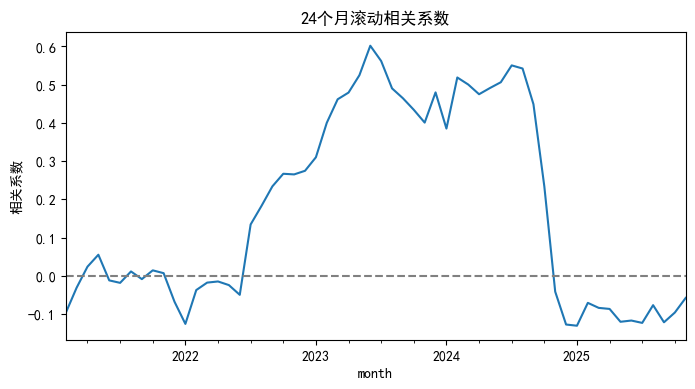

In [15]:
# -*- coding: utf-8 -*-
"""
时间序列精简版：教育文化娱乐 CPI vs 训练SnowNLP中心化
（已去掉 arch，仅保留平稳、协整、Granger、滚动相关）
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint, grangercausalitytests

# 1. 读数据
file_path = r'D:/NJU_WORKPIECE/期末：所有模型月度情感评分+经济指标.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1', index_col=0)
df.index = pd.to_datetime(df.index)

cpi_col = '居民消费价格指数(上年同月＝100)_教育文化娱乐_当期'
sent_col = 'nb中心化'
y1 = df[cpi_col].dropna()
y2 = df[sent_col].dropna()

common_idx = y1.index.intersection(y2.index)
y1, y2 = y1.loc[common_idx], y2.loc[common_idx]
print('样本期：', common_idx[0], '至', common_idx[-1], '共', len(common_idx), '个月')

# 2. 平稳性检验
def adf_test(sr, name):
    res = adfuller(sr, regression='ct')
    print(f'\n{name}  ADF={res[0]:.3f}, p={res[1]:.3f}')
    return res[1] < 0.05

y1_stationary = adf_test(y1, '教育文化娱乐CPI')
y2_stationary = adf_test(y2, 'nb中心化')

# 3. 协整
if not y1_stationary and not y2_stationary:
    eg_stat, eg_p, _ = coint(y1, y2, trend='ct')[:3]
    print(f'\nEngle-Granger 协整检验 stat={eg_stat:.3f}, p={eg_p:.3f}')
    cointegrated = eg_p < 0.05
else:
    cointegrated = False
    print('\n至少一个序列平稳，跳过协整检验')


# 4. Granger 因果
maxlag = 6
gc_res  = grangercausalitytests(pd.concat([y2, y1], axis=1), maxlag, verbose=False)
gpval   = gc_res[maxlag][0]['ssr_ftest'][1]      # 只取 p 值

gc_res2 = grangercausalitytests(pd.concat([y1, y2], axis=1), maxlag, verbose=False)
gpval2  = gc_res2[maxlag][0]['ssr_ftest'][1]

print(f'\n情绪→CPI  Granger p = {gpval:.3f}  {"拒绝" if gpval<0.05 else "不拒绝"}')
print(f'CPI→情绪  Granger p = {gpval2:.3f}  {"拒绝" if gpval2<0.05 else "不拒绝"}')

# 5. 滚动相关
window = 24
rolling_corr = y1.rolling(window).corr(y2).dropna()
plt.figure(figsize=(8, 4))
rolling_corr.plot(title=f'{window}个月滚动相关系数')
plt.axhline(0, color='grey', ls='--')
plt.ylabel('相关系数')
plt.show()

样本期： 2019-03-01 00:00:00 至 2025-11-01 00:00:00 共 81 个月

教育文化娱乐CPI  ADF=-1.912, p=0.649

hh原始得分  ADF=-5.258, p=0.000

至少一个序列平稳，跳过协整检验

情绪→CPI  Granger p = 0.460  不拒绝
CPI→情绪  Granger p = 0.589  不拒绝


C:\Anaconda\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


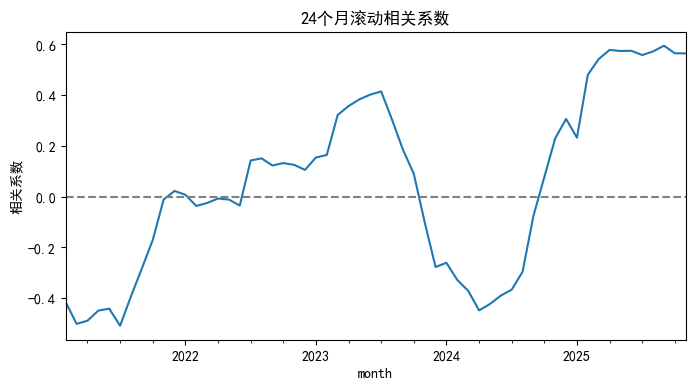

In [16]:
# -*- coding: utf-8 -*-
"""
时间序列精简版：教育文化娱乐 CPI vs 训练SnowNLP中心化
（已去掉 arch，仅保留平稳、协整、Granger、滚动相关）
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint, grangercausalitytests

# 1. 读数据
file_path = r'D:/NJU_WORKPIECE/期末：所有模型月度情感评分+经济指标.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1', index_col=0)
df.index = pd.to_datetime(df.index)

cpi_col = '居民消费价格指数(上年同月＝100)_教育文化娱乐_当期'
sent_col = 'hh原始得分'
y1 = df[cpi_col].dropna()
y2 = df[sent_col].dropna()

common_idx = y1.index.intersection(y2.index)
y1, y2 = y1.loc[common_idx], y2.loc[common_idx]
print('样本期：', common_idx[0], '至', common_idx[-1], '共', len(common_idx), '个月')

# 2. 平稳性检验
def adf_test(sr, name):
    res = adfuller(sr, regression='ct')
    print(f'\n{name}  ADF={res[0]:.3f}, p={res[1]:.3f}')
    return res[1] < 0.05

y1_stationary = adf_test(y1, '教育文化娱乐CPI')
y2_stationary = adf_test(y2, 'hh原始得分')

# 3. 协整
if not y1_stationary and not y2_stationary:
    eg_stat, eg_p, _ = coint(y1, y2, trend='ct')[:3]
    print(f'\nEngle-Granger 协整检验 stat={eg_stat:.3f}, p={eg_p:.3f}')
    cointegrated = eg_p < 0.05
else:
    cointegrated = False
    print('\n至少一个序列平稳，跳过协整检验')


# 4. Granger 因果
maxlag = 6
gc_res  = grangercausalitytests(pd.concat([y2, y1], axis=1), maxlag, verbose=False)
gpval   = gc_res[maxlag][0]['ssr_ftest'][1]      # 只取 p 值

gc_res2 = grangercausalitytests(pd.concat([y1, y2], axis=1), maxlag, verbose=False)
gpval2  = gc_res2[maxlag][0]['ssr_ftest'][1]

print(f'\n情绪→CPI  Granger p = {gpval:.3f}  {"拒绝" if gpval<0.05 else "不拒绝"}')
print(f'CPI→情绪  Granger p = {gpval2:.3f}  {"拒绝" if gpval2<0.05 else "不拒绝"}')

# 5. 滚动相关
window = 24
rolling_corr = y1.rolling(window).corr(y2).dropna()
plt.figure(figsize=(8, 4))
rolling_corr.plot(title=f'{window}个月滚动相关系数')
plt.axhline(0, color='grey', ls='--')
plt.ylabel('相关系数')
plt.show()

样本期： 2019-03-01 00:00:00 至 2025-11-01 00:00:00 共 81 个月

教育文化娱乐CPI  ADF=-1.912, p=0.649

hh中心化  ADF=-6.743, p=0.000

至少一个序列平稳，跳过协整检验

情绪→CPI  Granger p = 0.503  不拒绝
CPI→情绪  Granger p = 0.753  不拒绝


C:\Anaconda\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


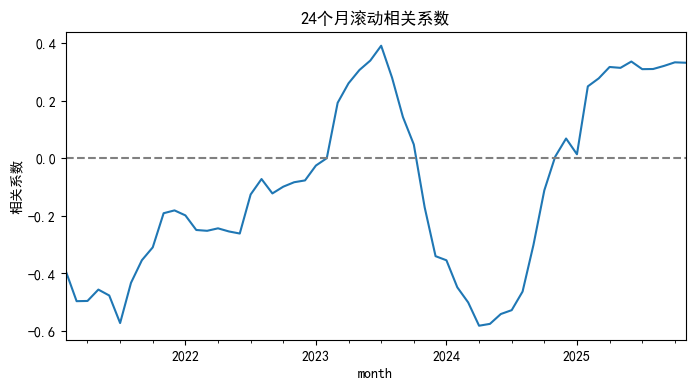

In [17]:
# -*- coding: utf-8 -*-
"""
时间序列精简版：教育文化娱乐 CPI vs 训练SnowNLP中心化
（已去掉 arch，仅保留平稳、协整、Granger、滚动相关）
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint, grangercausalitytests

# 1. 读数据
file_path = r'D:/NJU_WORKPIECE/期末：所有模型月度情感评分+经济指标.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1', index_col=0)
df.index = pd.to_datetime(df.index)

cpi_col = '居民消费价格指数(上年同月＝100)_教育文化娱乐_当期'
sent_col = 'hh中心化'
y1 = df[cpi_col].dropna()
y2 = df[sent_col].dropna()

common_idx = y1.index.intersection(y2.index)
y1, y2 = y1.loc[common_idx], y2.loc[common_idx]
print('样本期：', common_idx[0], '至', common_idx[-1], '共', len(common_idx), '个月')

# 2. 平稳性检验
def adf_test(sr, name):
    res = adfuller(sr, regression='ct')
    print(f'\n{name}  ADF={res[0]:.3f}, p={res[1]:.3f}')
    return res[1] < 0.05

y1_stationary = adf_test(y1, '教育文化娱乐CPI')
y2_stationary = adf_test(y2, 'hh中心化')

# 3. 协整
if not y1_stationary and not y2_stationary:
    eg_stat, eg_p, _ = coint(y1, y2, trend='ct')[:3]
    print(f'\nEngle-Granger 协整检验 stat={eg_stat:.3f}, p={eg_p:.3f}')
    cointegrated = eg_p < 0.05
else:
    cointegrated = False
    print('\n至少一个序列平稳，跳过协整检验')


# 4. Granger 因果
maxlag = 6
gc_res  = grangercausalitytests(pd.concat([y2, y1], axis=1), maxlag, verbose=False)
gpval   = gc_res[maxlag][0]['ssr_ftest'][1]      # 只取 p 值

gc_res2 = grangercausalitytests(pd.concat([y1, y2], axis=1), maxlag, verbose=False)
gpval2  = gc_res2[maxlag][0]['ssr_ftest'][1]

print(f'\n情绪→CPI  Granger p = {gpval:.3f}  {"拒绝" if gpval<0.05 else "不拒绝"}')
print(f'CPI→情绪  Granger p = {gpval2:.3f}  {"拒绝" if gpval2<0.05 else "不拒绝"}')

# 5. 滚动相关
window = 24
rolling_corr = y1.rolling(window).corr(y2).dropna()
plt.figure(figsize=(8, 4))
rolling_corr.plot(title=f'{window}个月滚动相关系数')
plt.axhline(0, color='grey', ls='--')
plt.ylabel('相关系数')
plt.show()

样本期： 2019-03-01 00:00:00 至 2025-11-01 00:00:00 共 81 个月

居民消费价格指数  ADF=-2.548, p=0.304

hh原始得分  ADF=-5.258, p=0.000

至少一个序列平稳，跳过协整检验

情绪→CPI  Granger p = 0.066  不拒绝
CPI→情绪  Granger p = 0.336  不拒绝


C:\Anaconda\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


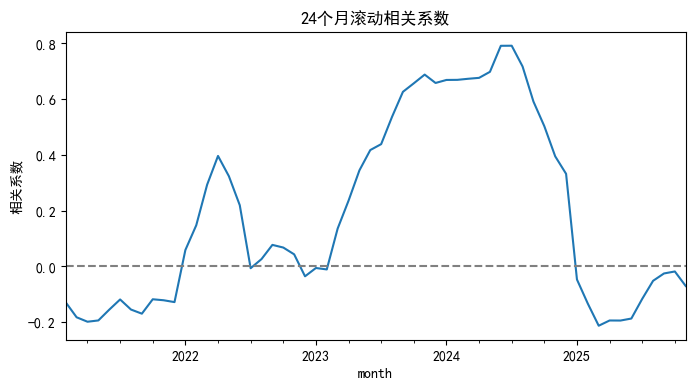

In [18]:
# -*- coding: utf-8 -*-
"""
时间序列精简版：教育文化娱乐 CPI vs 训练SnowNLP中心化
（已去掉 arch，仅保留平稳、协整、Granger、滚动相关）
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint, grangercausalitytests

# 1. 读数据
file_path = r'D:/NJU_WORKPIECE/期末：所有模型月度情感评分+经济指标.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1', index_col=0)
df.index = pd.to_datetime(df.index)

cpi_col = '居民消费价格指数(上年同月＝100)_当期'
sent_col = 'hh原始得分'
y1 = df[cpi_col].dropna()
y2 = df[sent_col].dropna()

common_idx = y1.index.intersection(y2.index)
y1, y2 = y1.loc[common_idx], y2.loc[common_idx]
print('样本期：', common_idx[0], '至', common_idx[-1], '共', len(common_idx), '个月')

# 2. 平稳性检验
def adf_test(sr, name):
    res = adfuller(sr, regression='ct')
    print(f'\n{name}  ADF={res[0]:.3f}, p={res[1]:.3f}')
    return res[1] < 0.05

y1_stationary = adf_test(y1, '居民消费价格指数')
y2_stationary = adf_test(y2, 'hh原始得分')

# 3. 协整
if not y1_stationary and not y2_stationary:
    eg_stat, eg_p, _ = coint(y1, y2, trend='ct')[:3]
    print(f'\nEngle-Granger 协整检验 stat={eg_stat:.3f}, p={eg_p:.3f}')
    cointegrated = eg_p < 0.05
else:
    cointegrated = False
    print('\n至少一个序列平稳，跳过协整检验')

# 4. Granger 因果
maxlag = 6
gc_res  = grangercausalitytests(pd.concat([y2, y1], axis=1), maxlag, verbose=False)
gpval   = gc_res[maxlag][0]['ssr_ftest'][1]      # 只取 p 值

gc_res2 = grangercausalitytests(pd.concat([y1, y2], axis=1), maxlag, verbose=False)
gpval2  = gc_res2[maxlag][0]['ssr_ftest'][1]

print(f'\n情绪→CPI  Granger p = {gpval:.3f}  {"拒绝" if gpval<0.05 else "不拒绝"}')
print(f'CPI→情绪  Granger p = {gpval2:.3f}  {"拒绝" if gpval2<0.05 else "不拒绝"}')

# 5. 滚动相关
window = 24
rolling_corr = y1.rolling(window).corr(y2).dropna()
plt.figure(figsize=(8, 4))
rolling_corr.plot(title=f'{window}个月滚动相关系数')
plt.axhline(0, color='grey', ls='--')
plt.ylabel('相关系数')
plt.show()

样本期： 2019-03-01 00:00:00 至 2025-11-01 00:00:00 共 81 个月

居民消费价格指数  ADF=-2.548, p=0.304

hh中心化  ADF=-6.743, p=0.000

至少一个序列平稳，跳过协整检验

情绪→CPI  Granger p = 0.069  不拒绝
CPI→情绪  Granger p = 0.571  不拒绝


C:\Anaconda\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


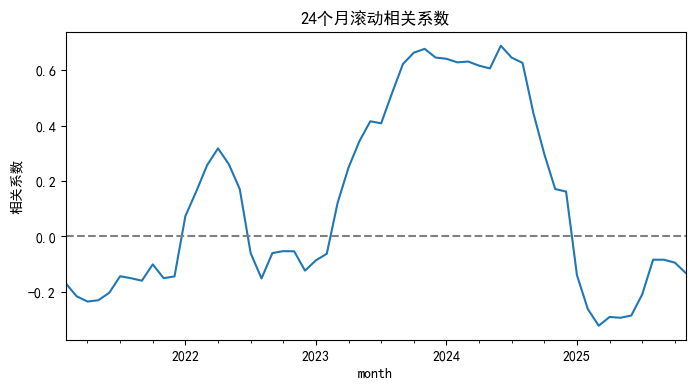

In [19]:
# -*- coding: utf-8 -*-
"""
时间序列精简版：教育文化娱乐 CPI vs 训练SnowNLP中心化
（已去掉 arch，仅保留平稳、协整、Granger、滚动相关）
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint, grangercausalitytests

# 1. 读数据
file_path = r'D:/NJU_WORKPIECE/期末：所有模型月度情感评分+经济指标.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1', index_col=0)
df.index = pd.to_datetime(df.index)

cpi_col = '居民消费价格指数(上年同月＝100)_当期'
sent_col = 'hh中心化'
y1 = df[cpi_col].dropna()
y2 = df[sent_col].dropna()

common_idx = y1.index.intersection(y2.index)
y1, y2 = y1.loc[common_idx], y2.loc[common_idx]
print('样本期：', common_idx[0], '至', common_idx[-1], '共', len(common_idx), '个月')

# 2. 平稳性检验
def adf_test(sr, name):
    res = adfuller(sr, regression='ct')
    print(f'\n{name}  ADF={res[0]:.3f}, p={res[1]:.3f}')
    return res[1] < 0.05

y1_stationary = adf_test(y1, '居民消费价格指数')
y2_stationary = adf_test(y2, 'hh中心化')

# 3. 协整
if not y1_stationary and not y2_stationary:
    eg_stat, eg_p, _ = coint(y1, y2, trend='ct')[:3]
    print(f'\nEngle-Granger 协整检验 stat={eg_stat:.3f}, p={eg_p:.3f}')
    cointegrated = eg_p < 0.05
else:
    cointegrated = False
    print('\n至少一个序列平稳，跳过协整检验')

# 4. Granger 因果
maxlag = 6
gc_res  = grangercausalitytests(pd.concat([y2, y1], axis=1), maxlag, verbose=False)
gpval   = gc_res[maxlag][0]['ssr_ftest'][1]      # 只取 p 值

gc_res2 = grangercausalitytests(pd.concat([y1, y2], axis=1), maxlag, verbose=False)
gpval2  = gc_res2[maxlag][0]['ssr_ftest'][1]

print(f'\n情绪→CPI  Granger p = {gpval:.3f}  {"拒绝" if gpval<0.05 else "不拒绝"}')
print(f'CPI→情绪  Granger p = {gpval2:.3f}  {"拒绝" if gpval2<0.05 else "不拒绝"}')

# 5. 滚动相关
window = 24
rolling_corr = y1.rolling(window).corr(y2).dropna()
plt.figure(figsize=(8, 4))
rolling_corr.plot(title=f'{window}个月滚动相关系数')
plt.axhline(0, color='grey', ls='--')
plt.ylabel('相关系数')
plt.show()

样本期： 2019-03-01 00:00:00 至 2025-11-01 00:00:00 共 81 个月

社会消费品零售总额当期值(亿元)  ADF=-3.211, p=0.082

hh中心化  ADF=-6.743, p=0.000

至少一个序列平稳，跳过协整检验

情绪→社会消费品零售总额当期值(亿元)  Granger p = 0.022  拒绝
社会消费品零售总额当期值(亿元)→情绪  Granger p = 0.067  不拒绝


C:\Anaconda\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


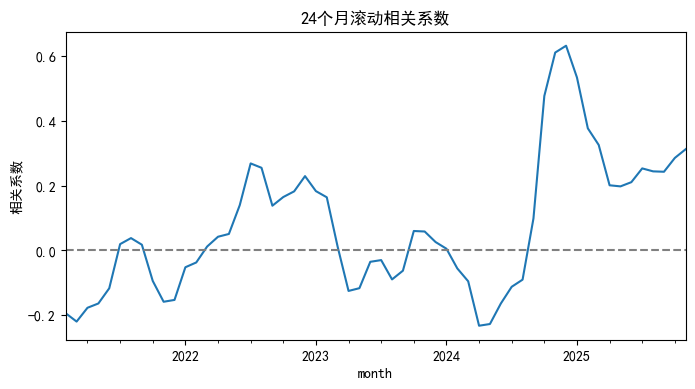

In [41]:
# -*- coding: utf-8 -*-
"""
时间序列精简版：教育文化娱乐 CPI vs 训练SnowNLP中心化
（已去掉 arch，仅保留平稳、协整、Granger、滚动相关）
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint, grangercausalitytests

# 1. 读数据
file_path = r'D:/NJU_WORKPIECE/期末：所有模型月度情感评分+经济指标.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1', index_col=0)
df.index = pd.to_datetime(df.index)

cpi_col = '社会消费品零售总额当期值(亿元)'
sent_col = 'hh中心化'
y1 = df[cpi_col].dropna()
y2 = df[sent_col].dropna()

common_idx = y1.index.intersection(y2.index)
y1, y2 = y1.loc[common_idx], y2.loc[common_idx]
print('样本期：', common_idx[0], '至', common_idx[-1], '共', len(common_idx), '个月')

# 2. 平稳性检验
def adf_test(sr, name):
    res = adfuller(sr, regression='ct')
    print(f'\n{name}  ADF={res[0]:.3f}, p={res[1]:.3f}')
    return res[1] < 0.05

y1_stationary = adf_test(y1, '社会消费品零售总额当期值(亿元)')
y2_stationary = adf_test(y2, 'hh中心化')

# 3. 协整
if not y1_stationary and not y2_stationary:
    eg_stat, eg_p, _ = coint(y1, y2, trend='ct')[:3]
    print(f'\nEngle-Granger 协整检验 stat={eg_stat:.3f}, p={eg_p:.3f}')
    cointegrated = eg_p < 0.05
else:
    cointegrated = False
    print('\n至少一个序列平稳，跳过协整检验')

# 4. Granger 因果
maxlag = 6
gc_res  = grangercausalitytests(pd.concat([y2, y1], axis=1), maxlag, verbose=False)
gpval   = gc_res[maxlag][0]['ssr_ftest'][1]      # 只取 p 值

gc_res2 = grangercausalitytests(pd.concat([y1, y2], axis=1), maxlag, verbose=False)
gpval2  = gc_res2[maxlag][0]['ssr_ftest'][1]

print(f'\n情绪→社会消费品零售总额当期值(亿元)  Granger p = {gpval:.3f}  {"拒绝" if gpval<0.05 else "不拒绝"}')
print(f'社会消费品零售总额当期值(亿元)→情绪  Granger p = {gpval2:.3f}  {"拒绝" if gpval2<0.05 else "不拒绝"}')

# 5. 滚动相关
window = 24
rolling_corr = y1.rolling(window).corr(y2).dropna()

plt.figure(figsize=(8, 4))
rolling_corr.plot(title=f'{window}个月滚动相关系数')
plt.axhline(0, color='grey', ls='--')
plt.ylabel('相关系数')

# 保存图片
save_path = r'D:/NJU_WORKPIECE/结果图集'
import os, datetime
os.makedirs(save_path, exist_ok=True)
plt.savefig(os.path.join(save_path,
            f'rolling_corr_{window}m_{datetime.datetime.now():%Y%m%d_%H%M%S}.png'),
            dpi=300, bbox_inches='tight')

plt.show()

样本期： 2019-03-01 00:00:00 至 2025-11-01 00:00:00 共 81 个月

社会消费品零售总额当期值(亿元)  ADF=-3.211, p=0.082

SnowNLP中心化  ADF=-9.439, p=0.000

至少一个序列平稳，跳过协整检验

情绪→社会消费品零售总额当期值(亿元)  Granger p = 0.000  拒绝
社会消费品零售总额当期值(亿元)→情绪  Granger p = 0.065  不拒绝


C:\Anaconda\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


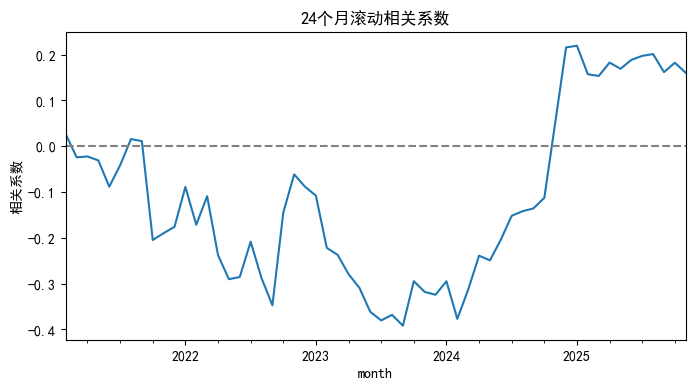

In [42]:
# -*- coding: utf-8 -*-
"""
时间序列精简版：教育文化娱乐 CPI vs 训练SnowNLP中心化
（已去掉 arch，仅保留平稳、协整、Granger、滚动相关）
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint, grangercausalitytests

# 1. 读数据
file_path = r'D:/NJU_WORKPIECE/期末：所有模型月度情感评分+经济指标.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1', index_col=0)
df.index = pd.to_datetime(df.index)

cpi_col = '社会消费品零售总额当期值(亿元)'
sent_col = 'snownlp中心化'
y1 = df[cpi_col].dropna()
y2 = df[sent_col].dropna()

common_idx = y1.index.intersection(y2.index)
y1, y2 = y1.loc[common_idx], y2.loc[common_idx]
print('样本期：', common_idx[0], '至', common_idx[-1], '共', len(common_idx), '个月')

# 2. 平稳性检验
def adf_test(sr, name):
    res = adfuller(sr, regression='ct')
    print(f'\n{name}  ADF={res[0]:.3f}, p={res[1]:.3f}')
    return res[1] < 0.05

y1_stationary = adf_test(y1, '社会消费品零售总额当期值(亿元)')
y2_stationary = adf_test(y2, 'SnowNLP中心化')

# 3. 协整
if not y1_stationary and not y2_stationary:
    eg_stat, eg_p, _ = coint(y1, y2, trend='ct')[:3]
    print(f'\nEngle-Granger 协整检验 stat={eg_stat:.3f}, p={eg_p:.3f}')
    cointegrated = eg_p < 0.05
else:
    cointegrated = False
    print('\n至少一个序列平稳，跳过协整检验')

# 4. Granger 因果
maxlag = 6
gc_res  = grangercausalitytests(pd.concat([y2, y1], axis=1), maxlag, verbose=False)
gpval   = gc_res[maxlag][0]['ssr_ftest'][1]      # 只取 p 值

gc_res2 = grangercausalitytests(pd.concat([y1, y2], axis=1), maxlag, verbose=False)
gpval2  = gc_res2[maxlag][0]['ssr_ftest'][1]

print(f'\n情绪→社会消费品零售总额当期值(亿元)  Granger p = {gpval:.3f}  {"拒绝" if gpval<0.05 else "不拒绝"}')
print(f'社会消费品零售总额当期值(亿元)→情绪  Granger p = {gpval2:.3f}  {"拒绝" if gpval2<0.05 else "不拒绝"}')

# 5. 滚动相关
window = 24
rolling_corr = y1.rolling(window).corr(y2).dropna()

plt.figure(figsize=(8, 4))
rolling_corr.plot(title=f'{window}个月滚动相关系数')
plt.axhline(0, color='grey', ls='--')
plt.ylabel('相关系数')

# 保存图片
save_path = r'D:/NJU_WORKPIECE/结果图集/snownlp/中心化'
import os, datetime
os.makedirs(save_path, exist_ok=True)
plt.savefig(os.path.join(save_path,
            f'rolling_corr_{window}m_{datetime.datetime.now():%Y%m%d_%H%M%S}.png'),
            dpi=300, bbox_inches='tight')

plt.show()

样本期： 2019-03-01 00:00:00 至 2025-11-01 00:00:00 共 81 个月

社会消费品零售总额当期值(亿元)  ADF=-3.211, p=0.082

训练SnowNLP中心化  ADF=-6.518, p=0.000

至少一个序列平稳，跳过协整检验

情绪→社会消费品零售总额当期值(亿元)  Granger p = 0.347  不拒绝
社会消费品零售总额当期值(亿元)→情绪  Granger p = 0.263  不拒绝


C:\Anaconda\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


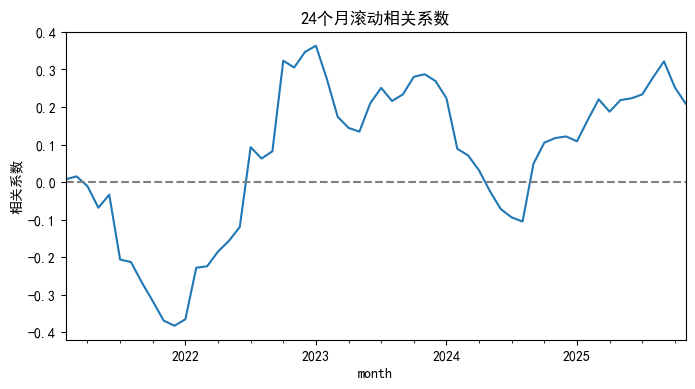

In [43]:
# -*- coding: utf-8 -*-
"""
时间序列精简版：教育文化娱乐 CPI vs 训练SnowNLP中心化
（已去掉 arch，仅保留平稳、协整、Granger、滚动相关）
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint, grangercausalitytests

# 1. 读数据
file_path = r'D:/NJU_WORKPIECE/期末：所有模型月度情感评分+经济指标.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1', index_col=0)
df.index = pd.to_datetime(df.index)

cpi_col = '社会消费品零售总额当期值(亿元)'
sent_col = '训练snownlp中心化'
y1 = df[cpi_col].dropna()
y2 = df[sent_col].dropna()

common_idx = y1.index.intersection(y2.index)
y1, y2 = y1.loc[common_idx], y2.loc[common_idx]
print('样本期：', common_idx[0], '至', common_idx[-1], '共', len(common_idx), '个月')

# 2. 平稳性检验
def adf_test(sr, name):
    res = adfuller(sr, regression='ct')
    print(f'\n{name}  ADF={res[0]:.3f}, p={res[1]:.3f}')
    return res[1] < 0.05

y1_stationary = adf_test(y1, '社会消费品零售总额当期值(亿元)')
y2_stationary = adf_test(y2, '训练SnowNLP中心化')

# 3. 协整
if not y1_stationary and not y2_stationary:
    eg_stat, eg_p, _ = coint(y1, y2, trend='ct')[:3]
    print(f'\nEngle-Granger 协整检验 stat={eg_stat:.3f}, p={eg_p:.3f}')
    cointegrated = eg_p < 0.05
else:
    cointegrated = False
    print('\n至少一个序列平稳，跳过协整检验')

# 4. Granger 因果
maxlag = 6
gc_res  = grangercausalitytests(pd.concat([y2, y1], axis=1), maxlag, verbose=False)
gpval   = gc_res[maxlag][0]['ssr_ftest'][1]      # 只取 p 值

gc_res2 = grangercausalitytests(pd.concat([y1, y2], axis=1), maxlag, verbose=False)
gpval2  = gc_res2[maxlag][0]['ssr_ftest'][1]

print(f'\n情绪→社会消费品零售总额当期值(亿元)  Granger p = {gpval:.3f}  {"拒绝" if gpval<0.05 else "不拒绝"}')
print(f'社会消费品零售总额当期值(亿元)→情绪  Granger p = {gpval2:.3f}  {"拒绝" if gpval2<0.05 else "不拒绝"}')

# 5. 滚动相关
window = 24
rolling_corr = y1.rolling(window).corr(y2).dropna()

plt.figure(figsize=(8, 4))
rolling_corr.plot(title=f'{window}个月滚动相关系数')
plt.axhline(0, color='grey', ls='--')
plt.ylabel('相关系数')

# 保存图片
save_path = r'D:/NJU_WORKPIECE/结果图集/训练snownlp/中心化/滚动相关系数.png'
import os, datetime
os.makedirs(save_path, exist_ok=True)
plt.savefig(os.path.join(save_path,
            f'rolling_corr_{window}m_{datetime.datetime.now():%Y%m%d_%H%M%S}.png'),
            dpi=300, bbox_inches='tight')

plt.show()

样本期： 2019-03-01 00:00:00 至 2025-11-01 00:00:00 共 81 个月

社会消费品零售总额当期值(亿元)  ADF=-3.211, p=0.082

svm中心化  ADF=-7.522, p=0.000

至少一个序列平稳，跳过协整检验

情绪→社会消费品零售总额当期值(亿元)  Granger p = 0.320  不拒绝
社会消费品零售总额当期值(亿元)→情绪  Granger p = 0.022  拒绝


C:\Anaconda\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


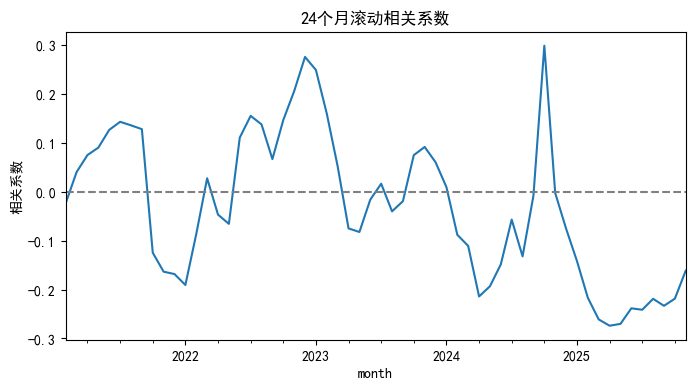

In [44]:
# -*- coding: utf-8 -*-
"""
时间序列精简版：教育文化娱乐 CPI vs 训练SnowNLP中心化
（已去掉 arch，仅保留平稳、协整、Granger、滚动相关）
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint, grangercausalitytests

# 1. 读数据
file_path = r'D:/NJU_WORKPIECE/期末：所有模型月度情感评分+经济指标.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1', index_col=0)
df.index = pd.to_datetime(df.index)

cpi_col = '社会消费品零售总额当期值(亿元)'
sent_col = 'svm中心化'
y1 = df[cpi_col].dropna()
y2 = df[sent_col].dropna()

common_idx = y1.index.intersection(y2.index)
y1, y2 = y1.loc[common_idx], y2.loc[common_idx]
print('样本期：', common_idx[0], '至', common_idx[-1], '共', len(common_idx), '个月')

# 2. 平稳性检验
def adf_test(sr, name):
    res = adfuller(sr, regression='ct')
    print(f'\n{name}  ADF={res[0]:.3f}, p={res[1]:.3f}')
    return res[1] < 0.05

y1_stationary = adf_test(y1, '社会消费品零售总额当期值(亿元)')
y2_stationary = adf_test(y2, 'svm中心化')

# 3. 协整
if not y1_stationary and not y2_stationary:
    eg_stat, eg_p, _ = coint(y1, y2, trend='ct')[:3]
    print(f'\nEngle-Granger 协整检验 stat={eg_stat:.3f}, p={eg_p:.3f}')
    cointegrated = eg_p < 0.05
else:
    cointegrated = False
    print('\n至少一个序列平稳，跳过协整检验')

# 4. Granger 因果
maxlag = 6
gc_res  = grangercausalitytests(pd.concat([y2, y1], axis=1), maxlag, verbose=False)
gpval   = gc_res[maxlag][0]['ssr_ftest'][1]      # 只取 p 值

gc_res2 = grangercausalitytests(pd.concat([y1, y2], axis=1), maxlag, verbose=False)
gpval2  = gc_res2[maxlag][0]['ssr_ftest'][1]

print(f'\n情绪→社会消费品零售总额当期值(亿元)  Granger p = {gpval:.3f}  {"拒绝" if gpval<0.05 else "不拒绝"}')
print(f'社会消费品零售总额当期值(亿元)→情绪  Granger p = {gpval2:.3f}  {"拒绝" if gpval2<0.05 else "不拒绝"}')

# 5. 滚动相关
window = 24
rolling_corr = y1.rolling(window).corr(y2).dropna()

plt.figure(figsize=(8, 4))
rolling_corr.plot(title=f'{window}个月滚动相关系数')
plt.axhline(0, color='grey', ls='--')
plt.ylabel('相关系数')

# 保存图片
save_path = r'D:/NJU_WORKPIECE/结果图集/svm/中心化/滚动相关系数.png'
import os, datetime
os.makedirs(save_path, exist_ok=True)
plt.savefig(os.path.join(save_path,
            f'rolling_corr_{window}m_{datetime.datetime.now():%Y%m%d_%H%M%S}.png'),
            dpi=300, bbox_inches='tight')

plt.show()

样本期： 2019-03-01 00:00:00 至 2025-11-01 00:00:00 共 81 个月

社会消费品零售总额当期值(亿元)  ADF=-3.211, p=0.082

nb中心化  ADF=-1.132, p=0.923

Engle-Granger 协整检验 stat=-2.456, p=0.545

情绪→社会消费品零售总额当期值(亿元)  Granger p = 0.088  不拒绝
社会消费品零售总额当期值(亿元)→情绪  Granger p = 0.695  不拒绝


C:\Anaconda\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


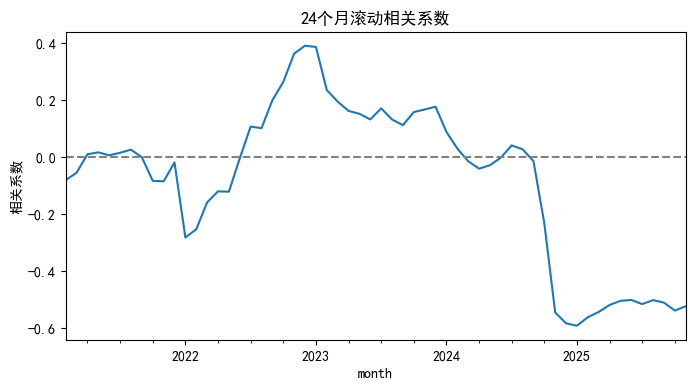

In [45]:
# -*- coding: utf-8 -*-
"""
时间序列精简版：教育文化娱乐 CPI vs 训练SnowNLP中心化
（已去掉 arch，仅保留平稳、协整、Granger、滚动相关）
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint, grangercausalitytests

# 1. 读数据
file_path = r'D:/NJU_WORKPIECE/期末：所有模型月度情感评分+经济指标.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1', index_col=0)
df.index = pd.to_datetime(df.index)

cpi_col = '社会消费品零售总额当期值(亿元)'
sent_col = 'nb中心化'
y1 = df[cpi_col].dropna()
y2 = df[sent_col].dropna()

common_idx = y1.index.intersection(y2.index)
y1, y2 = y1.loc[common_idx], y2.loc[common_idx]
print('样本期：', common_idx[0], '至', common_idx[-1], '共', len(common_idx), '个月')

# 2. 平稳性检验
def adf_test(sr, name):
    res = adfuller(sr, regression='ct')
    print(f'\n{name}  ADF={res[0]:.3f}, p={res[1]:.3f}')
    return res[1] < 0.05

y1_stationary = adf_test(y1, '社会消费品零售总额当期值(亿元)')
y2_stationary = adf_test(y2, 'nb中心化')

# 3. 协整
if not y1_stationary and not y2_stationary:
    eg_stat, eg_p, _ = coint(y1, y2, trend='ct')[:3]
    print(f'\nEngle-Granger 协整检验 stat={eg_stat:.3f}, p={eg_p:.3f}')
    cointegrated = eg_p < 0.05
else:
    cointegrated = False
    print('\n至少一个序列平稳，跳过协整检验')

# 4. Granger 因果
maxlag = 6
gc_res  = grangercausalitytests(pd.concat([y2, y1], axis=1), maxlag, verbose=False)
gpval   = gc_res[maxlag][0]['ssr_ftest'][1]      # 只取 p 值

gc_res2 = grangercausalitytests(pd.concat([y1, y2], axis=1), maxlag, verbose=False)
gpval2  = gc_res2[maxlag][0]['ssr_ftest'][1]

print(f'\n情绪→社会消费品零售总额当期值(亿元)  Granger p = {gpval:.3f}  {"拒绝" if gpval<0.05 else "不拒绝"}')
print(f'社会消费品零售总额当期值(亿元)→情绪  Granger p = {gpval2:.3f}  {"拒绝" if gpval2<0.05 else "不拒绝"}')

# 5. 滚动相关
window = 24
rolling_corr = y1.rolling(window).corr(y2).dropna()

plt.figure(figsize=(8, 4))
rolling_corr.plot(title=f'{window}个月滚动相关系数')
plt.axhline(0, color='grey', ls='--')
plt.ylabel('相关系数')

# 保存图片
save_path = r'D:/NJU_WORKPIECE/结果图集/nb/中心化/滚动相关系数.png'
import os, datetime
os.makedirs(save_path, exist_ok=True)
plt.savefig(os.path.join(save_path,
            f'rolling_corr_{window}m_{datetime.datetime.now():%Y%m%d_%H%M%S}.png'),
            dpi=300, bbox_inches='tight')

plt.show()

样本期： 2019-03-01 00:00:00 至 2025-11-01 00:00:00 共 81 个月

社会消费品零售总额当期值(亿元)  ADF=-3.211, p=0.082

SnowNLP原始得分  ADF=-9.093, p=0.000

至少一个序列平稳，跳过协整检验

情绪→社会消费品零售总额当期值(亿元)  Granger p = 0.000  拒绝
社会消费品零售总额当期值(亿元)→情绪  Granger p = 0.034  拒绝


C:\Anaconda\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


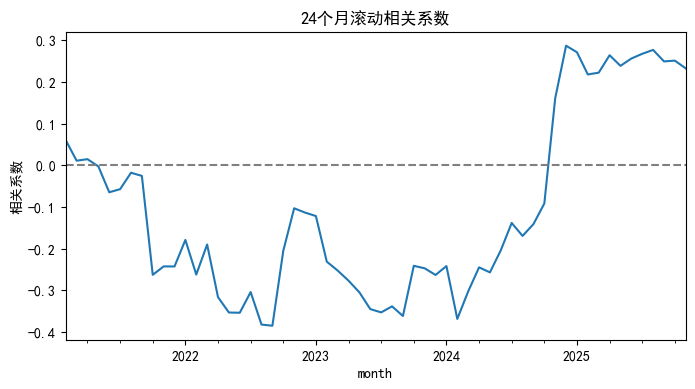

In [46]:
# -*- coding: utf-8 -*-
"""
时间序列精简版：教育文化娱乐 CPI vs 训练SnowNLP中心化
（已去掉 arch，仅保留平稳、协整、Granger、滚动相关）
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint, grangercausalitytests

# 1. 读数据
file_path = r'D:/NJU_WORKPIECE/期末：所有模型月度情感评分+经济指标.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1', index_col=0)
df.index = pd.to_datetime(df.index)

cpi_col = '社会消费品零售总额当期值(亿元)'
sent_col = 'snownlp原始得分'
y1 = df[cpi_col].dropna()
y2 = df[sent_col].dropna()

common_idx = y1.index.intersection(y2.index)
y1, y2 = y1.loc[common_idx], y2.loc[common_idx]
print('样本期：', common_idx[0], '至', common_idx[-1], '共', len(common_idx), '个月')

# 2. 平稳性检验
def adf_test(sr, name):
    res = adfuller(sr, regression='ct')
    print(f'\n{name}  ADF={res[0]:.3f}, p={res[1]:.3f}')
    return res[1] < 0.05

y1_stationary = adf_test(y1, '社会消费品零售总额当期值(亿元)')
y2_stationary = adf_test(y2, 'SnowNLP原始得分')

# 3. 协整
if not y1_stationary and not y2_stationary:
    eg_stat, eg_p, _ = coint(y1, y2, trend='ct')[:3]
    print(f'\nEngle-Granger 协整检验 stat={eg_stat:.3f}, p={eg_p:.3f}')
    cointegrated = eg_p < 0.05
else:
    cointegrated = False
    print('\n至少一个序列平稳，跳过协整检验')

# 4. Granger 因果
maxlag = 6
gc_res  = grangercausalitytests(pd.concat([y2, y1], axis=1), maxlag, verbose=False)
gpval   = gc_res[maxlag][0]['ssr_ftest'][1]      # 只取 p 值

gc_res2 = grangercausalitytests(pd.concat([y1, y2], axis=1), maxlag, verbose=False)
gpval2  = gc_res2[maxlag][0]['ssr_ftest'][1]

print(f'\n情绪→社会消费品零售总额当期值(亿元)  Granger p = {gpval:.3f}  {"拒绝" if gpval<0.05 else "不拒绝"}')
print(f'社会消费品零售总额当期值(亿元)→情绪  Granger p = {gpval2:.3f}  {"拒绝" if gpval2<0.05 else "不拒绝"}')

# 5. 滚动相关
window = 24
rolling_corr = y1.rolling(window).corr(y2).dropna()

plt.figure(figsize=(8, 4))
rolling_corr.plot(title=f'{window}个月滚动相关系数')
plt.axhline(0, color='grey', ls='--')
plt.ylabel('相关系数')

# 保存图片
save_path = r'D:/NJU_WORKPIECE/结果图集/snownlp/原始得分/滚动相关系数.png'
import os, datetime
os.makedirs(save_path, exist_ok=True)
plt.savefig(os.path.join(save_path,
            f'rolling_corr_{window}m_{datetime.datetime.now():%Y%m%d_%H%M%S}.png'),
            dpi=300, bbox_inches='tight')

plt.show()

样本期： 2019-03-01 00:00:00 至 2025-11-01 00:00:00 共 81 个月

社会消费品零售总额当期值(亿元)  ADF=-3.211, p=0.082

训练SnowNLP原始得分  ADF=-2.737, p=0.221

Engle-Granger 协整检验 stat=-3.515, p=0.096

情绪→社会消费品零售总额当期值(亿元)  Granger p = 0.689  不拒绝
社会消费品零售总额当期值(亿元)→情绪  Granger p = 0.076  不拒绝


C:\Anaconda\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


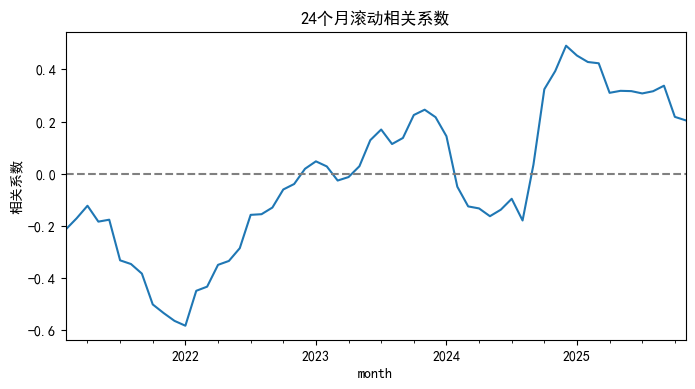

In [47]:
# -*- coding: utf-8 -*-
"""
时间序列精简版：教育文化娱乐 CPI vs 训练SnowNLP中心化
（已去掉 arch，仅保留平稳、协整、Granger、滚动相关）
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint, grangercausalitytests

# 1. 读数据
file_path = r'D:/NJU_WORKPIECE/期末：所有模型月度情感评分+经济指标.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1', index_col=0)
df.index = pd.to_datetime(df.index)

cpi_col = '社会消费品零售总额当期值(亿元)'
sent_col = '训练snownlp原始得分'
y1 = df[cpi_col].dropna()
y2 = df[sent_col].dropna()

common_idx = y1.index.intersection(y2.index)
y1, y2 = y1.loc[common_idx], y2.loc[common_idx]
print('样本期：', common_idx[0], '至', common_idx[-1], '共', len(common_idx), '个月')

# 2. 平稳性检验
def adf_test(sr, name):
    res = adfuller(sr, regression='ct')
    print(f'\n{name}  ADF={res[0]:.3f}, p={res[1]:.3f}')
    return res[1] < 0.05

y1_stationary = adf_test(y1, '社会消费品零售总额当期值(亿元)')
y2_stationary = adf_test(y2, '训练SnowNLP原始得分')

# 3. 协整
if not y1_stationary and not y2_stationary:
    eg_stat, eg_p, _ = coint(y1, y2, trend='ct')[:3]
    print(f'\nEngle-Granger 协整检验 stat={eg_stat:.3f}, p={eg_p:.3f}')
    cointegrated = eg_p < 0.05
else:
    cointegrated = False
    print('\n至少一个序列平稳，跳过协整检验')

# 4. Granger 因果
maxlag = 6
gc_res  = grangercausalitytests(pd.concat([y2, y1], axis=1), maxlag, verbose=False)
gpval   = gc_res[maxlag][0]['ssr_ftest'][1]      # 只取 p 值

gc_res2 = grangercausalitytests(pd.concat([y1, y2], axis=1), maxlag, verbose=False)
gpval2  = gc_res2[maxlag][0]['ssr_ftest'][1]

print(f'\n情绪→社会消费品零售总额当期值(亿元)  Granger p = {gpval:.3f}  {"拒绝" if gpval<0.05 else "不拒绝"}')
print(f'社会消费品零售总额当期值(亿元)→情绪  Granger p = {gpval2:.3f}  {"拒绝" if gpval2<0.05 else "不拒绝"}')

# 5. 滚动相关
window = 24
rolling_corr = y1.rolling(window).corr(y2).dropna()

plt.figure(figsize=(8, 4))
rolling_corr.plot(title=f'{window}个月滚动相关系数')
plt.axhline(0, color='grey', ls='--')
plt.ylabel('相关系数')

# 保存图片
save_path = r'D:/NJU_WORKPIECE/结果图集/训练snownlp/原始得分/滚动相关系数.png'
import os, datetime
os.makedirs(save_path, exist_ok=True)
plt.savefig(os.path.join(save_path,
            f'rolling_corr_{window}m_{datetime.datetime.now():%Y%m%d_%H%M%S}.png'),
            dpi=300, bbox_inches='tight')

plt.show()

样本期： 2019-03-01 00:00:00 至 2025-11-01 00:00:00 共 81 个月

社会消费品零售总额当期值(亿元)  ADF=-3.211, p=0.082

nb原始得分  ADF=-1.717, p=0.743

Engle-Granger 协整检验 stat=-2.884, p=0.317

情绪→社会消费品零售总额当期值(亿元)  Granger p = 0.010  拒绝
社会消费品零售总额当期值(亿元)→情绪  Granger p = 0.002  拒绝


C:\Anaconda\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


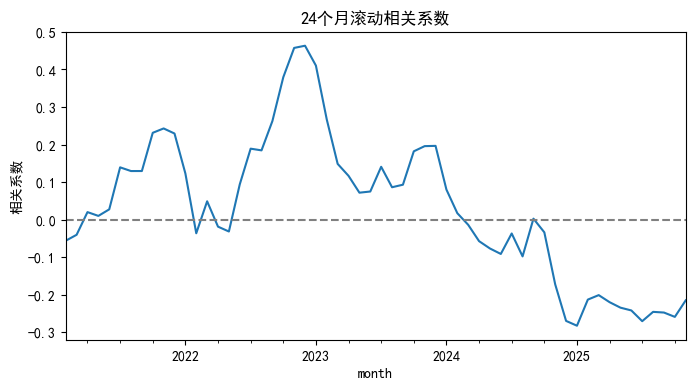

In [48]:
# -*- coding: utf-8 -*-
"""
时间序列精简版：教育文化娱乐 CPI vs 训练SnowNLP中心化
（已去掉 arch，仅保留平稳、协整、Granger、滚动相关）
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint, grangercausalitytests

# 1. 读数据
file_path = r'D:/NJU_WORKPIECE/期末：所有模型月度情感评分+经济指标.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1', index_col=0)
df.index = pd.to_datetime(df.index)

cpi_col = '社会消费品零售总额当期值(亿元)'
sent_col = 'nb原始得分'
y1 = df[cpi_col].dropna()
y2 = df[sent_col].dropna()

common_idx = y1.index.intersection(y2.index)
y1, y2 = y1.loc[common_idx], y2.loc[common_idx]
print('样本期：', common_idx[0], '至', common_idx[-1], '共', len(common_idx), '个月')

# 2. 平稳性检验
def adf_test(sr, name):
    res = adfuller(sr, regression='ct')
    print(f'\n{name}  ADF={res[0]:.3f}, p={res[1]:.3f}')
    return res[1] < 0.05

y1_stationary = adf_test(y1, '社会消费品零售总额当期值(亿元)')
y2_stationary = adf_test(y2, 'nb原始得分')

# 3. 协整
if not y1_stationary and not y2_stationary:
    eg_stat, eg_p, _ = coint(y1, y2, trend='ct')[:3]
    print(f'\nEngle-Granger 协整检验 stat={eg_stat:.3f}, p={eg_p:.3f}')
    cointegrated = eg_p < 0.05
else:
    cointegrated = False
    print('\n至少一个序列平稳，跳过协整检验')

# 4. Granger 因果
maxlag = 6
gc_res  = grangercausalitytests(pd.concat([y2, y1], axis=1), maxlag, verbose=False)
gpval   = gc_res[maxlag][0]['ssr_ftest'][1]      # 只取 p 值

gc_res2 = grangercausalitytests(pd.concat([y1, y2], axis=1), maxlag, verbose=False)
gpval2  = gc_res2[maxlag][0]['ssr_ftest'][1]

print(f'\n情绪→社会消费品零售总额当期值(亿元)  Granger p = {gpval:.3f}  {"拒绝" if gpval<0.05 else "不拒绝"}')
print(f'社会消费品零售总额当期值(亿元)→情绪  Granger p = {gpval2:.3f}  {"拒绝" if gpval2<0.05 else "不拒绝"}')

# 5. 滚动相关
window = 24
rolling_corr = y1.rolling(window).corr(y2).dropna()

plt.figure(figsize=(8, 4))
rolling_corr.plot(title=f'{window}个月滚动相关系数')
plt.axhline(0, color='grey', ls='--')
plt.ylabel('相关系数')

# 保存图片
save_path = r'D:/NJU_WORKPIECE/结果图集/nb/原始得分/滚动相关系数.png'
import os, datetime
os.makedirs(save_path, exist_ok=True)
plt.savefig(os.path.join(save_path,
            f'rolling_corr_{window}m_{datetime.datetime.now():%Y%m%d_%H%M%S}.png'),
            dpi=300, bbox_inches='tight')

plt.show()

样本期： 2019-03-01 00:00:00 至 2025-11-01 00:00:00 共 81 个月

社会消费品零售总额当期值(亿元)  ADF=-3.211, p=0.082

svm原始得分  ADF=-5.299, p=0.000

至少一个序列平稳，跳过协整检验

情绪→社会消费品零售总额当期值(亿元)  Granger p = 0.188  不拒绝
社会消费品零售总额当期值(亿元)→情绪  Granger p = 0.001  拒绝


C:\Anaconda\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


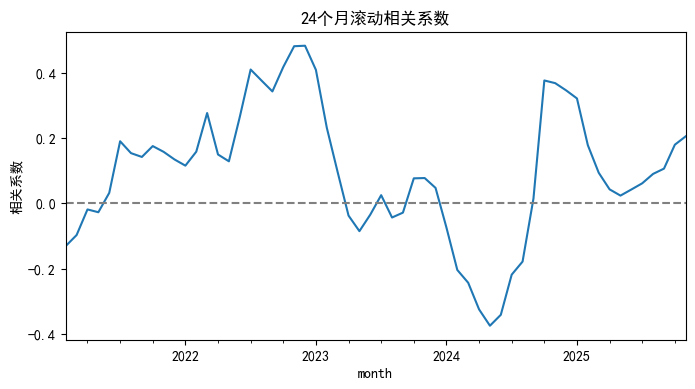

In [49]:
# -*- coding: utf-8 -*-
"""
时间序列精简版：教育文化娱乐 CPI vs 训练SnowNLP中心化
（已去掉 arch，仅保留平稳、协整、Granger、滚动相关）
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint, grangercausalitytests

# 1. 读数据
file_path = r'D:/NJU_WORKPIECE/期末：所有模型月度情感评分+经济指标.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1', index_col=0)
df.index = pd.to_datetime(df.index)

cpi_col = '社会消费品零售总额当期值(亿元)'
sent_col = 'svm原始得分'
y1 = df[cpi_col].dropna()
y2 = df[sent_col].dropna()

common_idx = y1.index.intersection(y2.index)
y1, y2 = y1.loc[common_idx], y2.loc[common_idx]
print('样本期：', common_idx[0], '至', common_idx[-1], '共', len(common_idx), '个月')

# 2. 平稳性检验
def adf_test(sr, name):
    res = adfuller(sr, regression='ct')
    print(f'\n{name}  ADF={res[0]:.3f}, p={res[1]:.3f}')
    return res[1] < 0.05

y1_stationary = adf_test(y1, '社会消费品零售总额当期值(亿元)')
y2_stationary = adf_test(y2, 'svm原始得分')

# 3. 协整
if not y1_stationary and not y2_stationary:
    eg_stat, eg_p, _ = coint(y1, y2, trend='ct')[:3]
    print(f'\nEngle-Granger 协整检验 stat={eg_stat:.3f}, p={eg_p:.3f}')
    cointegrated = eg_p < 0.05
else:
    cointegrated = False
    print('\n至少一个序列平稳，跳过协整检验')

# 4. Granger 因果
maxlag = 6
gc_res  = grangercausalitytests(pd.concat([y2, y1], axis=1), maxlag, verbose=False)
gpval   = gc_res[maxlag][0]['ssr_ftest'][1]      # 只取 p 值

gc_res2 = grangercausalitytests(pd.concat([y1, y2], axis=1), maxlag, verbose=False)
gpval2  = gc_res2[maxlag][0]['ssr_ftest'][1]

print(f'\n情绪→社会消费品零售总额当期值(亿元)  Granger p = {gpval:.3f}  {"拒绝" if gpval<0.05 else "不拒绝"}')
print(f'社会消费品零售总额当期值(亿元)→情绪  Granger p = {gpval2:.3f}  {"拒绝" if gpval2<0.05 else "不拒绝"}')

# 5. 滚动相关
window = 24
rolling_corr = y1.rolling(window).corr(y2).dropna()

plt.figure(figsize=(8, 4))
rolling_corr.plot(title=f'{window}个月滚动相关系数')
plt.axhline(0, color='grey', ls='--')
plt.ylabel('相关系数')

# 保存图片
save_path = r'D:/NJU_WORKPIECE/结果图集/svm/原始得分/滚动相关系数.png'
import os, datetime
os.makedirs(save_path, exist_ok=True)
plt.savefig(os.path.join(save_path,
            f'rolling_corr_{window}m_{datetime.datetime.now():%Y%m%d_%H%M%S}.png'),
            dpi=300, bbox_inches='tight')

plt.show()

样本期： 2019-03-01 00:00:00 至 2025-11-01 00:00:00 共 81 个月

社会消费品零售总额当期值(亿元)  ADF=-3.211, p=0.082

hh原始得分  ADF=-5.258, p=0.000

至少一个序列平稳，跳过协整检验

情绪→社会消费品零售总额当期值(亿元)  Granger p = 0.137  不拒绝
社会消费品零售总额当期值(亿元)→情绪  Granger p = 0.043  拒绝


C:\Anaconda\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


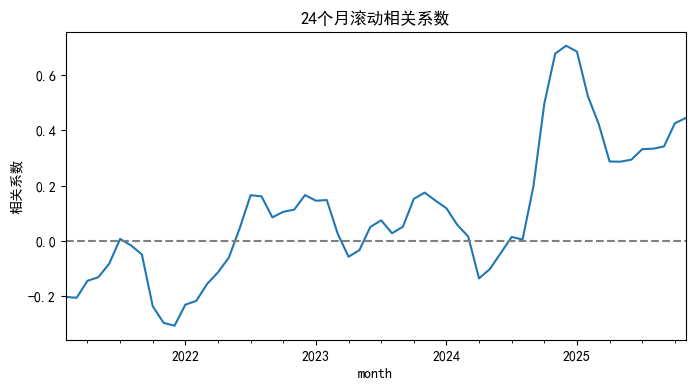

In [50]:
# -*- coding: utf-8 -*-
"""
时间序列精简版：教育文化娱乐 CPI vs 训练SnowNLP中心化
（已去掉 arch，仅保留平稳、协整、Granger、滚动相关）
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint, grangercausalitytests

# 1. 读数据
file_path = r'D:/NJU_WORKPIECE/期末：所有模型月度情感评分+经济指标.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1', index_col=0)
df.index = pd.to_datetime(df.index)

cpi_col = '社会消费品零售总额当期值(亿元)'
sent_col = 'hh原始得分'
y1 = df[cpi_col].dropna()
y2 = df[sent_col].dropna()

common_idx = y1.index.intersection(y2.index)
y1, y2 = y1.loc[common_idx], y2.loc[common_idx]
print('样本期：', common_idx[0], '至', common_idx[-1], '共', len(common_idx), '个月')

# 2. 平稳性检验
def adf_test(sr, name):
    res = adfuller(sr, regression='ct')
    print(f'\n{name}  ADF={res[0]:.3f}, p={res[1]:.3f}')
    return res[1] < 0.05

y1_stationary = adf_test(y1, '社会消费品零售总额当期值(亿元)')
y2_stationary = adf_test(y2, 'hh原始得分')

# 3. 协整
if not y1_stationary and not y2_stationary:
    eg_stat, eg_p, _ = coint(y1, y2, trend='ct')[:3]
    print(f'\nEngle-Granger 协整检验 stat={eg_stat:.3f}, p={eg_p:.3f}')
    cointegrated = eg_p < 0.05
else:
    cointegrated = False
    print('\n至少一个序列平稳，跳过协整检验')

# 4. Granger 因果
maxlag = 6
gc_res  = grangercausalitytests(pd.concat([y2, y1], axis=1), maxlag, verbose=False)
gpval   = gc_res[maxlag][0]['ssr_ftest'][1]      # 只取 p 值

gc_res2 = grangercausalitytests(pd.concat([y1, y2], axis=1), maxlag, verbose=False)
gpval2  = gc_res2[maxlag][0]['ssr_ftest'][1]

print(f'\n情绪→社会消费品零售总额当期值(亿元)  Granger p = {gpval:.3f}  {"拒绝" if gpval<0.05 else "不拒绝"}')
print(f'社会消费品零售总额当期值(亿元)→情绪  Granger p = {gpval2:.3f}  {"拒绝" if gpval2<0.05 else "不拒绝"}')

# 5. 滚动相关
window = 24
rolling_corr = y1.rolling(window).corr(y2).dropna()

plt.figure(figsize=(8, 4))
rolling_corr.plot(title=f'{window}个月滚动相关系数')
plt.axhline(0, color='grey', ls='--')
plt.ylabel('相关系数')

# 保存图片
save_path = r'D:/NJU_WORKPIECE/结果图集/hh/原始得分/滚动相关系数.png'
import os, datetime
os.makedirs(save_path, exist_ok=True)
plt.savefig(os.path.join(save_path,
            f'rolling_corr_{window}m_{datetime.datetime.now():%Y%m%d_%H%M%S}.png'),
            dpi=300, bbox_inches='tight')

plt.show()

样本期： 2019-03-01 00:00:00 至 2025-11-01 00:00:00 共 81 个月

社会消费品零售总额当期值(亿元)  ADF=-3.211, p=0.082

snownlp标题修正  ADF=-9.348, p=0.000

至少一个序列平稳，跳过协整检验

情绪→社会消费品零售总额当期值(亿元)  Granger p = 0.001  拒绝
社会消费品零售总额当期值(亿元)→情绪  Granger p = 0.120  不拒绝


C:\Anaconda\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


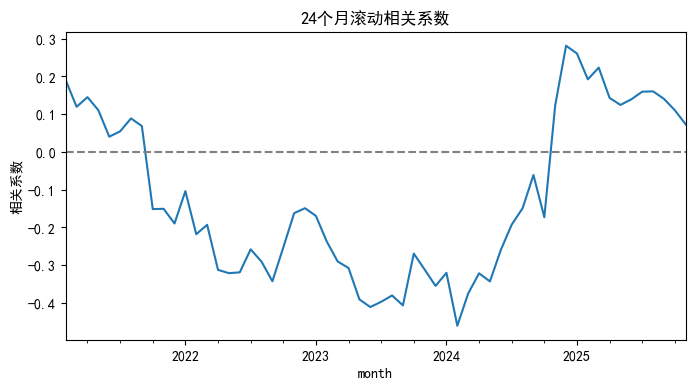

In [51]:
# -*- coding: utf-8 -*-
"""
时间序列精简版：教育文化娱乐 CPI vs 训练SnowNLP中心化
（已去掉 arch，仅保留平稳、协整、Granger、滚动相关）
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint, grangercausalitytests

# 1. 读数据
file_path = r'D:/NJU_WORKPIECE/期末：所有模型月度情感评分+经济指标.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1', index_col=0)
df.index = pd.to_datetime(df.index)

cpi_col = '社会消费品零售总额当期值(亿元)'
sent_col = 'snownlp标题修正'
y1 = df[cpi_col].dropna()
y2 = df[sent_col].dropna()

common_idx = y1.index.intersection(y2.index)
y1, y2 = y1.loc[common_idx], y2.loc[common_idx]
print('样本期：', common_idx[0], '至', common_idx[-1], '共', len(common_idx), '个月')

# 2. 平稳性检验
def adf_test(sr, name):
    res = adfuller(sr, regression='ct')
    print(f'\n{name}  ADF={res[0]:.3f}, p={res[1]:.3f}')
    return res[1] < 0.05

y1_stationary = adf_test(y1, '社会消费品零售总额当期值(亿元)')
y2_stationary = adf_test(y2, 'snownlp标题修正')

# 3. 协整
if not y1_stationary and not y2_stationary:
    eg_stat, eg_p, _ = coint(y1, y2, trend='ct')[:3]
    print(f'\nEngle-Granger 协整检验 stat={eg_stat:.3f}, p={eg_p:.3f}')
    cointegrated = eg_p < 0.05
else:
    cointegrated = False
    print('\n至少一个序列平稳，跳过协整检验')

# 4. Granger 因果
maxlag = 6
gc_res  = grangercausalitytests(pd.concat([y2, y1], axis=1), maxlag, verbose=False)
gpval   = gc_res[maxlag][0]['ssr_ftest'][1]      # 只取 p 值

gc_res2 = grangercausalitytests(pd.concat([y1, y2], axis=1), maxlag, verbose=False)
gpval2  = gc_res2[maxlag][0]['ssr_ftest'][1]

print(f'\n情绪→社会消费品零售总额当期值(亿元)  Granger p = {gpval:.3f}  {"拒绝" if gpval<0.05 else "不拒绝"}')
print(f'社会消费品零售总额当期值(亿元)→情绪  Granger p = {gpval2:.3f}  {"拒绝" if gpval2<0.05 else "不拒绝"}')

# 5. 滚动相关
window = 24
rolling_corr = y1.rolling(window).corr(y2).dropna()

plt.figure(figsize=(8, 4))
rolling_corr.plot(title=f'{window}个月滚动相关系数')
plt.axhline(0, color='grey', ls='--')
plt.ylabel('相关系数')

# 保存图片
save_path = r'D:/NJU_WORKPIECE/结果图集/snownlp/标题修正/滚动相关系数.png'
import os, datetime
os.makedirs(save_path, exist_ok=True)
plt.savefig(os.path.join(save_path,
            f'rolling_corr_{window}m_{datetime.datetime.now():%Y%m%d_%H%M%S}.png'),
            dpi=300, bbox_inches='tight')

plt.show()

样本期： 2019-03-01 00:00:00 至 2025-11-01 00:00:00 共 81 个月

社会消费品零售总额当期值(亿元)  ADF=-3.211, p=0.082

训练snownlp标题修正  ADF=-2.834, p=0.185

Engle-Granger 协整检验 stat=-3.531, p=0.093

情绪→社会消费品零售总额当期值(亿元)  Granger p = 0.751  不拒绝
社会消费品零售总额当期值(亿元)→情绪  Granger p = 0.113  不拒绝


C:\Anaconda\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


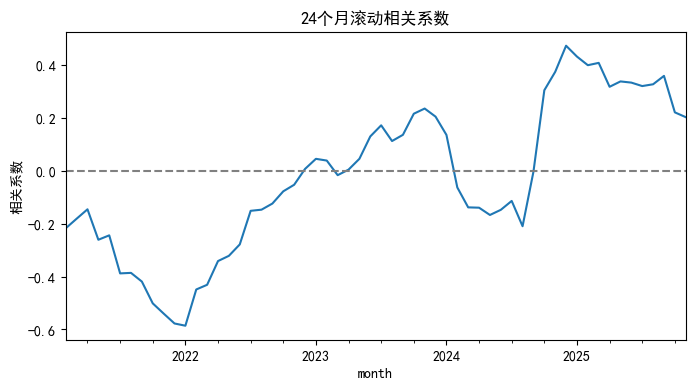

In [52]:
# -*- coding: utf-8 -*-
"""
时间序列精简版：教育文化娱乐 CPI vs 训练SnowNLP中心化
（已去掉 arch，仅保留平稳、协整、Granger、滚动相关）
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint, grangercausalitytests

# 1. 读数据
file_path = r'D:/NJU_WORKPIECE/期末：所有模型月度情感评分+经济指标.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1', index_col=0)
df.index = pd.to_datetime(df.index)

cpi_col = '社会消费品零售总额当期值(亿元)'
sent_col = '训练snownlp标题修正'
y1 = df[cpi_col].dropna()
y2 = df[sent_col].dropna()

common_idx = y1.index.intersection(y2.index)
y1, y2 = y1.loc[common_idx], y2.loc[common_idx]
print('样本期：', common_idx[0], '至', common_idx[-1], '共', len(common_idx), '个月')

# 2. 平稳性检验
def adf_test(sr, name):
    res = adfuller(sr, regression='ct')
    print(f'\n{name}  ADF={res[0]:.3f}, p={res[1]:.3f}')
    return res[1] < 0.05

y1_stationary = adf_test(y1, '社会消费品零售总额当期值(亿元)')
y2_stationary = adf_test(y2, '训练snownlp标题修正')

# 3. 协整
if not y1_stationary and not y2_stationary:
    eg_stat, eg_p, _ = coint(y1, y2, trend='ct')[:3]
    print(f'\nEngle-Granger 协整检验 stat={eg_stat:.3f}, p={eg_p:.3f}')
    cointegrated = eg_p < 0.05
else:
    cointegrated = False
    print('\n至少一个序列平稳，跳过协整检验')

# 4. Granger 因果
maxlag = 6
gc_res  = grangercausalitytests(pd.concat([y2, y1], axis=1), maxlag, verbose=False)
gpval   = gc_res[maxlag][0]['ssr_ftest'][1]      # 只取 p 值

gc_res2 = grangercausalitytests(pd.concat([y1, y2], axis=1), maxlag, verbose=False)
gpval2  = gc_res2[maxlag][0]['ssr_ftest'][1]

print(f'\n情绪→社会消费品零售总额当期值(亿元)  Granger p = {gpval:.3f}  {"拒绝" if gpval<0.05 else "不拒绝"}')
print(f'社会消费品零售总额当期值(亿元)→情绪  Granger p = {gpval2:.3f}  {"拒绝" if gpval2<0.05 else "不拒绝"}')

# 5. 滚动相关
window = 24
rolling_corr = y1.rolling(window).corr(y2).dropna()

plt.figure(figsize=(8, 4))
rolling_corr.plot(title=f'{window}个月滚动相关系数')
plt.axhline(0, color='grey', ls='--')
plt.ylabel('相关系数')

# 保存图片
save_path = r'D:/NJU_WORKPIECE/结果图集/训练snownlp/标题修正/滚动相关系数.png'
import os, datetime
os.makedirs(save_path, exist_ok=True)
plt.savefig(os.path.join(save_path,
            f'rolling_corr_{window}m_{datetime.datetime.now():%Y%m%d_%H%M%S}.png'),
            dpi=300, bbox_inches='tight')

plt.show()

样本期： 2019-03-01 00:00:00 至 2025-11-01 00:00:00 共 81 个月

社会消费品零售总额当期值(亿元)  ADF=-3.211, p=0.082

svm标题修正  ADF=-6.177, p=0.000

至少一个序列平稳，跳过协整检验

情绪→社会消费品零售总额当期值(亿元)  Granger p = 0.327  不拒绝
社会消费品零售总额当期值(亿元)→情绪  Granger p = 0.010  拒绝


C:\Anaconda\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


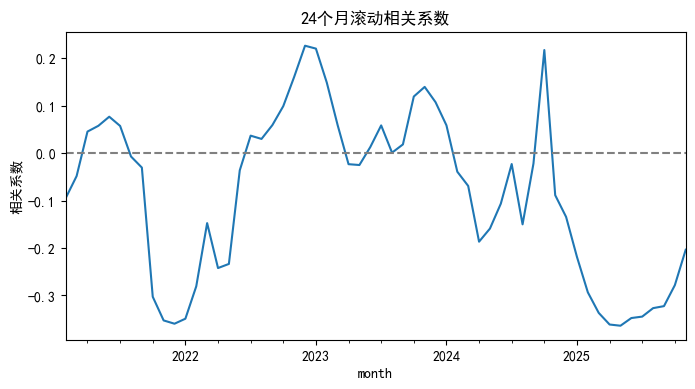

In [53]:
# -*- coding: utf-8 -*-
"""
时间序列精简版：教育文化娱乐 CPI vs 训练SnowNLP中心化
（已去掉 arch，仅保留平稳、协整、Granger、滚动相关）
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint, grangercausalitytests

# 1. 读数据
file_path = r'D:/NJU_WORKPIECE/期末：所有模型月度情感评分+经济指标.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1', index_col=0)
df.index = pd.to_datetime(df.index)

cpi_col = '社会消费品零售总额当期值(亿元)'
sent_col = 'svm标题修正'
y1 = df[cpi_col].dropna()
y2 = df[sent_col].dropna()

common_idx = y1.index.intersection(y2.index)
y1, y2 = y1.loc[common_idx], y2.loc[common_idx]
print('样本期：', common_idx[0], '至', common_idx[-1], '共', len(common_idx), '个月')

# 2. 平稳性检验
def adf_test(sr, name):
    res = adfuller(sr, regression='ct')
    print(f'\n{name}  ADF={res[0]:.3f}, p={res[1]:.3f}')
    return res[1] < 0.05

y1_stationary = adf_test(y1, '社会消费品零售总额当期值(亿元)')
y2_stationary = adf_test(y2, 'svm标题修正')

# 3. 协整
if not y1_stationary and not y2_stationary:
    eg_stat, eg_p, _ = coint(y1, y2, trend='ct')[:3]
    print(f'\nEngle-Granger 协整检验 stat={eg_stat:.3f}, p={eg_p:.3f}')
    cointegrated = eg_p < 0.05
else:
    cointegrated = False
    print('\n至少一个序列平稳，跳过协整检验')

# 4. Granger 因果
maxlag = 6
gc_res  = grangercausalitytests(pd.concat([y2, y1], axis=1), maxlag, verbose=False)
gpval   = gc_res[maxlag][0]['ssr_ftest'][1]      # 只取 p 值

gc_res2 = grangercausalitytests(pd.concat([y1, y2], axis=1), maxlag, verbose=False)
gpval2  = gc_res2[maxlag][0]['ssr_ftest'][1]

print(f'\n情绪→社会消费品零售总额当期值(亿元)  Granger p = {gpval:.3f}  {"拒绝" if gpval<0.05 else "不拒绝"}')
print(f'社会消费品零售总额当期值(亿元)→情绪  Granger p = {gpval2:.3f}  {"拒绝" if gpval2<0.05 else "不拒绝"}')

# 5. 滚动相关
window = 24
rolling_corr = y1.rolling(window).corr(y2).dropna()

plt.figure(figsize=(8, 4))
rolling_corr.plot(title=f'{window}个月滚动相关系数')
plt.axhline(0, color='grey', ls='--')
plt.ylabel('相关系数')

# 保存图片
save_path = r'D:/NJU_WORKPIECE/结果图集/svm/标题修正/滚动相关系数.png'
import os, datetime
os.makedirs(save_path, exist_ok=True)
plt.savefig(os.path.join(save_path,
            f'rolling_corr_{window}m_{datetime.datetime.now():%Y%m%d_%H%M%S}.png'),
            dpi=300, bbox_inches='tight')

plt.show()

样本期： 2019-03-01 00:00:00 至 2025-11-01 00:00:00 共 81 个月

社会消费品零售总额当期值(亿元)  ADF=-3.211, p=0.082

nb标题修正  ADF=-5.723, p=0.000

至少一个序列平稳，跳过协整检验

情绪→社会消费品零售总额当期值(亿元)  Granger p = 0.096  不拒绝
社会消费品零售总额当期值(亿元)→情绪  Granger p = 0.739  不拒绝


C:\Anaconda\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


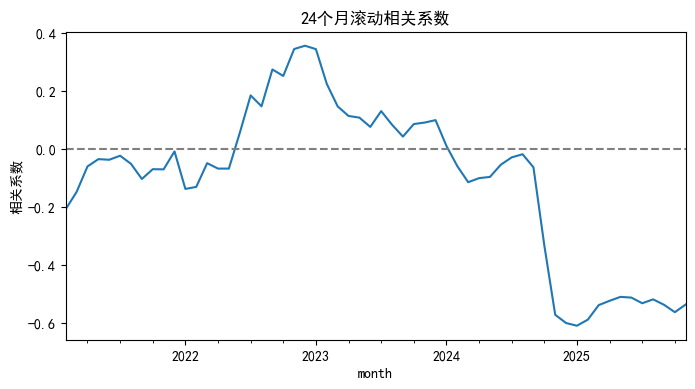

In [54]:
# -*- coding: utf-8 -*-
"""
时间序列精简版：教育文化娱乐 CPI vs 训练SnowNLP中心化
（已去掉 arch，仅保留平稳、协整、Granger、滚动相关）
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint, grangercausalitytests

# 1. 读数据
file_path = r'D:/NJU_WORKPIECE/期末：所有模型月度情感评分+经济指标.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1', index_col=0)
df.index = pd.to_datetime(df.index)

cpi_col = '社会消费品零售总额当期值(亿元)'
sent_col = 'nb标题修正'
y1 = df[cpi_col].dropna()
y2 = df[sent_col].dropna()

common_idx = y1.index.intersection(y2.index)
y1, y2 = y1.loc[common_idx], y2.loc[common_idx]
print('样本期：', common_idx[0], '至', common_idx[-1], '共', len(common_idx), '个月')

# 2. 平稳性检验
def adf_test(sr, name):
    res = adfuller(sr, regression='ct')
    print(f'\n{name}  ADF={res[0]:.3f}, p={res[1]:.3f}')
    return res[1] < 0.05

y1_stationary = adf_test(y1, '社会消费品零售总额当期值(亿元)')
y2_stationary = adf_test(y2, 'nb标题修正')

# 3. 协整
if not y1_stationary and not y2_stationary:
    eg_stat, eg_p, _ = coint(y1, y2, trend='ct')[:3]
    print(f'\nEngle-Granger 协整检验 stat={eg_stat:.3f}, p={eg_p:.3f}')
    cointegrated = eg_p < 0.05
else:
    cointegrated = False
    print('\n至少一个序列平稳，跳过协整检验')

# 4. Granger 因果
maxlag = 6
gc_res  = grangercausalitytests(pd.concat([y2, y1], axis=1), maxlag, verbose=False)
gpval   = gc_res[maxlag][0]['ssr_ftest'][1]      # 只取 p 值

gc_res2 = grangercausalitytests(pd.concat([y1, y2], axis=1), maxlag, verbose=False)
gpval2  = gc_res2[maxlag][0]['ssr_ftest'][1]

print(f'\n情绪→社会消费品零售总额当期值(亿元)  Granger p = {gpval:.3f}  {"拒绝" if gpval<0.05 else "不拒绝"}')
print(f'社会消费品零售总额当期值(亿元)→情绪  Granger p = {gpval2:.3f}  {"拒绝" if gpval2<0.05 else "不拒绝"}')

# 5. 滚动相关
window = 24
rolling_corr = y1.rolling(window).corr(y2).dropna()

plt.figure(figsize=(8, 4))
rolling_corr.plot(title=f'{window}个月滚动相关系数')
plt.axhline(0, color='grey', ls='--')
plt.ylabel('相关系数')

# 保存图片
save_path = r'D:/NJU_WORKPIECE/结果图集/nb/标题修正/滚动相关系数.png'
import os, datetime
os.makedirs(save_path, exist_ok=True)
plt.savefig(os.path.join(save_path,
            f'rolling_corr_{window}m_{datetime.datetime.now():%Y%m%d_%H%M%S}.png'),
            dpi=300, bbox_inches='tight')

plt.show()

In [26]:
训练后snownlp、nb不太好，中心化：snownlp>hh（情绪->社零）显著性都还可以 svm是相反（情绪<-社零）；
训练后snownlp、nb，标题修正：snownlp（情绪->社零）显著性不错    svm是相反（情绪<-社零）
snownlp原始得分、nb出现伪回归；训练snownlp原始得分\hh不太好(显著性不强)；svm原始得分则是社零预测情绪（SVM 原始得分与 SnowNLP/hh 的量纲、分布、对语义敏感度不同。
SVM 得分可能更多捕捉“事后吐槽”（买完再评论），而非“事前预期”（想买前先讨论）。结果就变成：当官方社零数据公布或实际消费升温后，网友才在弹幕里滞后地表达“买了”“涨价了”，于是出现社零→情绪显著。）


样本期： 2019-04-01 00:00:00 至 2025-11-01 00:00:00 共 80 个月

工业生产者出厂价格指数_差分  ADF=-3.151, p=0.095

snownlp标题修正_差分  ADF=-7.040, p=0.000

至少一个序列平稳，跳过协整检验

情绪_差分→工业生产者出厂价格指数_差分  Granger p = 0.836  不拒绝
工业生产者出厂价格指数_差分→情绪_差分  Granger p = 0.874  不拒绝


C:\Anaconda\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


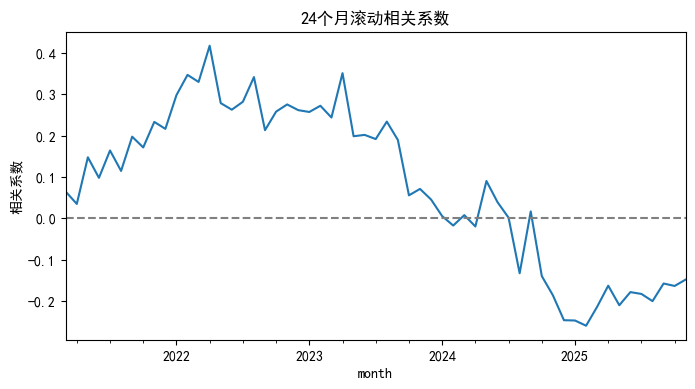

In [65]:
# -*- coding: utf-8 -*-
"""
时间序列精简版：教育文化娱乐 CPI vs 训练SnowNLP中心化
（已去掉 arch，仅保留平稳、协整、Granger、滚动相关）
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint, grangercausalitytests

# 1. 读数据
file_path = r'D:/NJU_WORKPIECE/期末：所有模型月度情感评分+经济指标_差分2.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1', index_col=0)
df.index = pd.to_datetime(df.index)

cpi_col = '工业生产者出厂价格指数_差分'
sent_col = 'snownlp标题修正_差分'
y1 = df[cpi_col].dropna()
y2 = df[sent_col].dropna()

common_idx = y1.index.intersection(y2.index)
y1, y2 = y1.loc[common_idx], y2.loc[common_idx]
print('样本期：', common_idx[0], '至', common_idx[-1], '共', len(common_idx), '个月')

# 2. 平稳性检验
def adf_test(sr, name):
    res = adfuller(sr, regression='ct')
    print(f'\n{name}  ADF={res[0]:.3f}, p={res[1]:.3f}')
    return res[1] < 0.05

y1_stationary = adf_test(y1, '工业生产者出厂价格指数_差分')
y2_stationary = adf_test(y2, 'snownlp标题修正_差分')

# 3. 协整
if not y1_stationary and not y2_stationary:
    eg_stat, eg_p, _ = coint(y1, y2, trend='ct')[:3]
    print(f'\nEngle-Granger 协整检验 stat={eg_stat:.3f}, p={eg_p:.3f}')
    cointegrated = eg_p < 0.05
else:
    cointegrated = False
    print('\n至少一个序列平稳，跳过协整检验')

# 4. Granger 因果
maxlag = 6
gc_res  = grangercausalitytests(pd.concat([y2, y1], axis=1), maxlag, verbose=False)
gpval   = gc_res[maxlag][0]['ssr_ftest'][1]      # 只取 p 值

gc_res2 = grangercausalitytests(pd.concat([y1, y2], axis=1), maxlag, verbose=False)
gpval2  = gc_res2[maxlag][0]['ssr_ftest'][1]

print(f'\n情绪_差分→工业生产者出厂价格指数_差分  Granger p = {gpval:.3f}  {"拒绝" if gpval<0.05 else "不拒绝"}')
print(f'工业生产者出厂价格指数_差分→情绪_差分  Granger p = {gpval2:.3f}  {"拒绝" if gpval2<0.05 else "不拒绝"}')

# 5. 滚动相关
window = 24
rolling_corr = y1.rolling(window).corr(y2).dropna()

plt.figure(figsize=(8, 4))
rolling_corr.plot(title=f'{window}个月滚动相关系数')
plt.axhline(0, color='grey', ls='--')
plt.ylabel('相关系数')
plt.show()